# PGScen — Analysis and Validation on NYISO Data (New York)

This notebook reproduces for the **NYISO (New York)** region the analyses and validations
carried out for Texas (ERCOT) in the paper *"Joint Granular Model for Load, Solar
and Wind Power Scenario Generation"* (Carmona & Yang, IEEE).

**Contents:**
1. Loading and exploring NYISO data
2. Load scenario generation
3. Wind scenario generation
4. Solar scenario generation (PCA)
5. Analysis of spatio-temporal correlations (GEMINI)
6. Monte Carlo scenario visualization
7. Quantitative evaluation (Energy Scores & Variograms)
8. Multi-day execution and robustness analysis

**Prerequisite:** PGScen installed (`pip install .` from the cloned repo)

In [34]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

# Force the notebook to use the workspace copy of pgscen, not the conda-installed one.
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
for name in list(sys.modules):
    if name == 'pgscen' or name.startswith('pgscen.'):
        del sys.modules[name]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import time

import pgscen
from pgscen.engine import GeminiEngine
from pgscen.pca import PCAGeminiEngine
from pgscen.utils.data_utils import (
    load_ny_load_data, load_ny_wind_data, load_ny_solar_data,
    split_actuals_hist_future, split_forecasts_hist_future
)
from pgscen.scoring import compute_energy_scores, compute_variograms

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print('Imports OK')
print('Using pgscen from:', list(pgscen.__path__)[0])

Imports OK
Using pgscen from: /Users/val/Desktop/Princeton/PGscen-main/pgscen


---
## 1. Loading and Exploring NYISO Data

This notebook supports two data sources:
- **Load**: real NYISO data (downloaded via `download_nyiso_real_load.py`) or NREL/PERFORM synthetic data
- **Wind**: NREL/PERFORM data by site (2019)
- **Solar**: NREL/PERFORM data by site (2018-2019)

Set `USE_REAL_NYISO_LOAD = True` in the next cell to use real operational data.

### Data Source Selection

This notebook supports two data sources for **load**:

| Source | Description | Pros | Cons |
|--------|-------------|------|------|
| **NREL/PERFORM** | Synthetic data bundled with PGScen | Ready to use, consistent with wind/solar | Not real market data |
| **Real NYISO** | Downloaded from `mis.nyiso.com` via `download_nyiso_real_load.py` | Real operational data | Requires download step; load = net load (includes BTM solar effect) |

Set `USE_REAL_NYISO_LOAD = True` below to use real data.  
Wind and solar remain on NREL/PERFORM data (no public site-level real data available).

In [35]:
# ══════════════════════════════════════════════════════════════
#  DATA SOURCE CONFIGURATION
# ══════════════════════════════════════════════════════════════
USE_REAL_NYISO_LOAD = True   # ← Set to False to use NREL/PERFORM data
REAL_DATA_DIR = './data/NYISO_real'  # Path to downloaded real NYISO CSVs

# --- Load data ---
if USE_REAL_NYISO_LOAD:
    try:
        # Import the loading function from the download script
        # (download_nyiso_real_load.py must be in the working directory or on sys.path)
        from download_nyiso_real_load import load_real_ny_load_data
        load_actual, load_forecast = load_real_ny_load_data(REAL_DATA_DIR)
        print('✓ Using REAL NYISO load data')
        print('  ⚠ Note: load = net load (generation + net interchange).')
        print('    BTM solar is already subtracted from the measured load.')
    except (ImportError, FileNotFoundError) as e:
        print(f'⚠ Could not load real NYISO data: {e}')
        print('  Falling back to NREL/PERFORM data.')
        print('  To use real data, run: python download_nyiso_real_load.py')
        load_actual, load_forecast = load_ny_load_data()
        USE_REAL_NYISO_LOAD = False
else:
    load_actual, load_forecast = load_ny_load_data()
    print('Using NREL/PERFORM load data (bundled with PGScen)')

# --- Wind & Solar data (always NREL/PERFORM) ---
wind_actual, wind_forecast, wind_meta = load_ny_wind_data()
solar_actual, solar_forecast, solar_meta = load_ny_solar_data()

# --- Summary ---
print(f'\n=== LOAD {"(REAL)" if USE_REAL_NYISO_LOAD else "(NREL)"} ===')
print(f'  Actuals: {load_actual.shape} — {load_actual.index.min()} → {load_actual.index.max()}')
print(f'  Zones: {list(load_actual.columns)}')
print(f'  Forecasts: {load_forecast.shape}')
print(f'  Issue_time range: {load_forecast["Issue_time"].min()} → {load_forecast["Issue_time"].max()}')

print(f'\n=== WIND (NREL/PERFORM) ===')
print(f'  Actuals: {wind_actual.shape} — {wind_actual.index.min()} → {wind_actual.index.max()}')
print(f'  Sites: {wind_actual.shape[1]}')

print(f'\n=== SOLAR (NREL/PERFORM) ===')
print(f'  Actuals: {solar_actual.shape} — {solar_actual.index.min()} → {solar_actual.index.max()}')
print(f'  Sites: {solar_actual.shape[1]}')


Chargement actuals:   data/NYISO_real/load_actual_1h_zone_2018_2019_2020_2021_2022_2023_2024_2025_utc.csv
Chargement forecasts: data/NYISO_real/load_day_ahead_forecast_zone_2018_2019_2020_2021_2022_2023_2024_2025_utc.csv
  Filtering: dropped 2 incomplete forecast blocks (kept 2921/2923)
✓ Using REAL NYISO load data
  ⚠ Note: load = net load (generation + net interchange).
    BTM solar is already subtracted from the measured load.

=== LOAD (REAL) ===
  Actuals: (70128, 12) — 2018-01-01 05:00:00+00:00 → 2026-01-01 04:00:00+00:00
  Zones: ['CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'HUD VL', 'LONGIL', 'MHK VL', 'MILLWD', 'N.Y.C.', 'NORTH', 'WEST', 'NYCA']
  Forecasts: (70104, 14)
  Issue_time range: 2018-01-01 18:00:00+00:00 → 2025-12-30 18:00:00+00:00

=== WIND (NREL/PERFORM) ===
  Actuals: (8760, 80) — 2019-01-01 00:00:00+00:00 → 2019-12-31 23:00:00+00:00
  Sites: 80

=== SOLAR (NREL/PERFORM) ===
  Actuals: (17520, 314) — 2018-01-01 00:00:00+00:00 → 2019-12-31 23:00:00+00:00
  Sites: 314

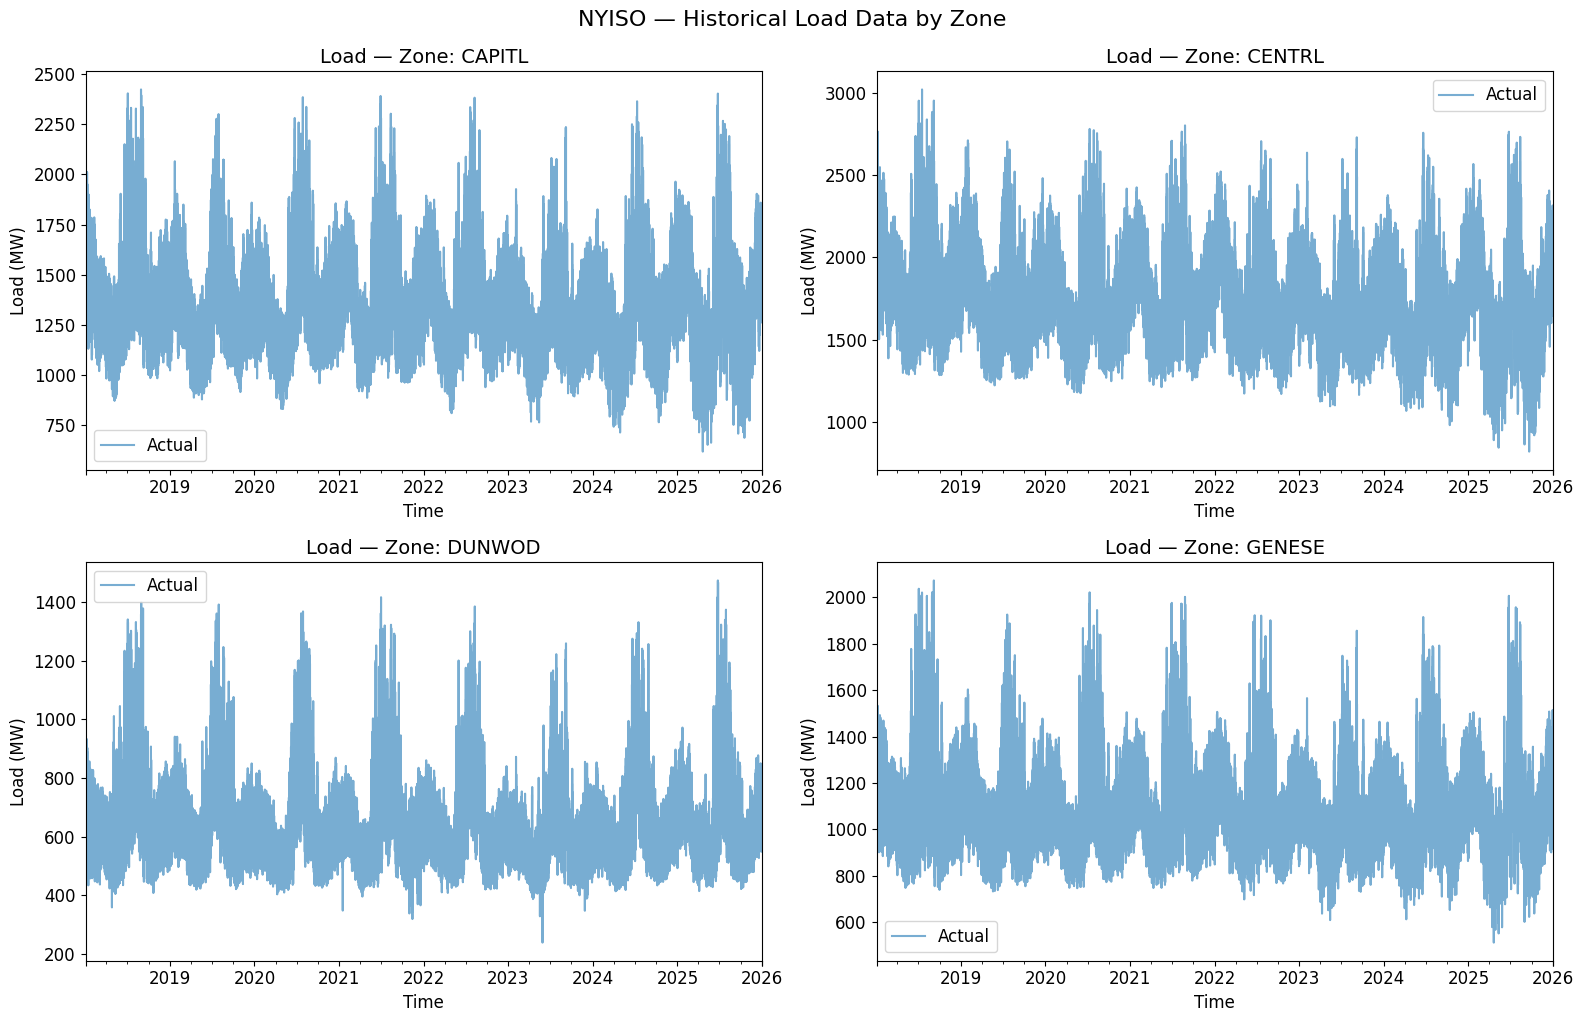

In [36]:
# --- Exploratory visualization of load data ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
zones = load_actual.columns[:4]

for ax, zone in zip(axes.flat, zones):
    load_actual[zone].plot(ax=ax, alpha=0.6, label='Actual')
    ax.set_title(f'Load — Zone: {zone}')
    ax.set_ylabel('Load (MW)')
    ax.legend()

plt.tight_layout()
plt.suptitle('NYISO — Historical Load Data by Zone', y=1.02, fontsize=16)
plt.show()

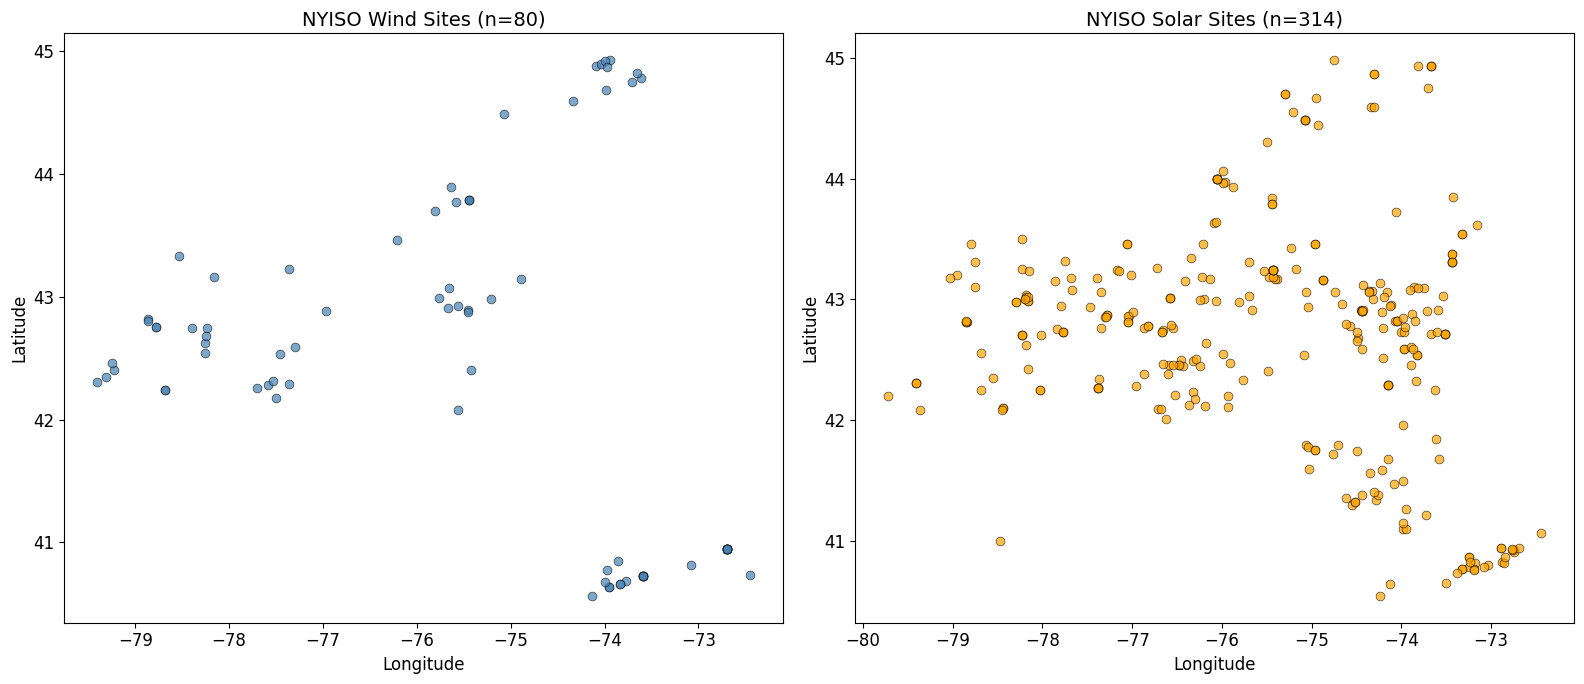

In [37]:
# --- Wind and solar site map (if lat/lon are available) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

if 'Latitude' in wind_meta.columns and 'Longitude' in wind_meta.columns:
    axes[0].scatter(wind_meta['Longitude'], wind_meta['Latitude'], 
                    c='steelblue', s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
    axes[0].set_title(f'NYISO Wind Sites (n={len(wind_meta)})')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
else:
    # Try alternative column names
    lat_col = [c for c in wind_meta.columns if 'lat' in c.lower()]
    lon_col = [c for c in wind_meta.columns if 'lon' in c.lower()]
    if lat_col and lon_col:
        axes[0].scatter(wind_meta[lon_col[0]], wind_meta[lat_col[0]], 
                        c='steelblue', s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
        axes[0].set_title(f'NYISO Wind Sites (n={len(wind_meta)})')
        axes[0].set_xlabel('Longitude')
        axes[0].set_ylabel('Latitude')
    else:
        axes[0].text(0.5, 0.5, 'No coordinates available in wind_meta', 
                     ha='center', transform=axes[0].transAxes)

if 'Latitude' in solar_meta.columns and 'Longitude' in solar_meta.columns:
    axes[1].scatter(solar_meta['Longitude'], solar_meta['Latitude'], 
                    c='orange', s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
    axes[1].set_title(f'NYISO Solar Sites (n={len(solar_meta)})')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
else:
    lat_col = [c for c in solar_meta.columns if 'lat' in c.lower()]
    lon_col = [c for c in solar_meta.columns if 'lon' in c.lower()]
    if lat_col and lon_col:
        axes[1].scatter(solar_meta[lon_col[0]], solar_meta[lat_col[0]], 
                        c='orange', s=40, alpha=0.7, edgecolors='k', linewidths=0.5)
        axes[1].set_title(f'NYISO Solar Sites (n={len(solar_meta)})')
        axes[1].set_xlabel('Longitude')
        axes[1].set_ylabel('Latitude')
    else:
        axes[1].text(0.5, 0.5, 'No coordinates available in solar_meta', 
                     ha='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

---
## 2. Load Scenario Generation (NYISO)

We follow the same procedure as for Texas:
- Historical / future split (out-of-sample)
- GEMINI model fit with GPD marginals
- Monte Carlo scenario generation

In [38]:
# --- Parameters ---
# Choose a target date within the range of your load data.
# NREL/PERFORM covers 2018-2019; real NYISO data covers 2010-2025 (depending on download).

if USE_REAL_NYISO_LOAD:
    SCEN_DATE = '2023-06-15'  # With real data, we can use more recent dates
else:
    SCEN_DATE = '2019-06-15'  # NREL data limited to 2018-2019

N_SCENARIOS = 1000
ASSET_RHO = 0.1
TIME_RHO = 0.1
START_HOUR = '00:00:00'

scen_start = pd.Timestamp(f'{SCEN_DATE} {START_HOUR}', tz='UTC')
scen_timesteps = pd.date_range(scen_start, periods=24, freq='h')

# Verify the date falls within available data
if scen_timesteps[0] < load_actual.index.min() or scen_timesteps[-1] > load_actual.index.max():
    print(f'⚠ WARNING: {SCEN_DATE} is outside the load data range!')
    print(f'  Available: {load_actual.index.min().date()} → {load_actual.index.max().date()}')
else:
    print(f'✓ Date {SCEN_DATE} is within data range')

print(f'Timesteps: {scen_timesteps[0]} → {scen_timesteps[-1]}')
print(f'Scenarios: {N_SCENARIOS}')


✓ Date 2023-06-15 is within data range
Timesteps: 2023-06-15 00:00:00+00:00 → 2023-06-15 23:00:00+00:00
Scenarios: 1000


In [39]:
# --- LOAD scenario generation ---
t0 = time.time()

load_actual_hist, load_actual_future = split_actuals_hist_future(
    load_actual, scen_timesteps, in_sample=False)
load_forecast_hist, load_forecast_future = split_forecasts_hist_future(
    load_forecast, scen_timesteps, in_sample=False)

load_engn = GeminiEngine(
    load_actual_hist, load_forecast_hist,
    scen_timesteps[0], asset_type='load',
    forecast_lead_time_in_hour=6
)

load_engn.fit(ASSET_RHO, TIME_RHO)
load_engn.create_scenario(N_SCENARIOS, load_forecast_future)

print(f"Load scenarios generated in {time.time()-t0:.1f}s")
print(f"Scenario shape: {load_engn.scenarios['load'].shape}")

Load scenarios generated in 2.9s
Scenario shape: (1000, 288)


In [40]:
# --- LOAD scenario generation ---
t0 = time.time()

load_actual_hist, load_actual_future = split_actuals_hist_future(
    load_actual, scen_timesteps, in_sample=False)
load_forecast_hist, load_forecast_future = split_forecasts_hist_future(
    load_forecast, scen_timesteps, in_sample=False)

load_engn = GeminiEngine(
    load_actual_hist, load_forecast_hist,
    scen_timesteps[0], asset_type='load',
    forecast_lead_time_in_hour=6
)
load_engn.fit(ASSET_RHO, TIME_RHO)
load_engn.create_scenario(N_SCENARIOS, load_forecast_future)

print(f"Load scenarios generated in {time.time()-t0:.1f}s")
print(f"Scenario shape: {load_engn.scenarios['load'].shape}")

Load scenarios generated in 2.9s
Scenario shape: (1000, 288)


### 2.1 Load Deviation Analysis — Q-Q Plots

We check for heavy tails in the marginal distributions of
load deviations (see Figure 1 of the paper for Texas).

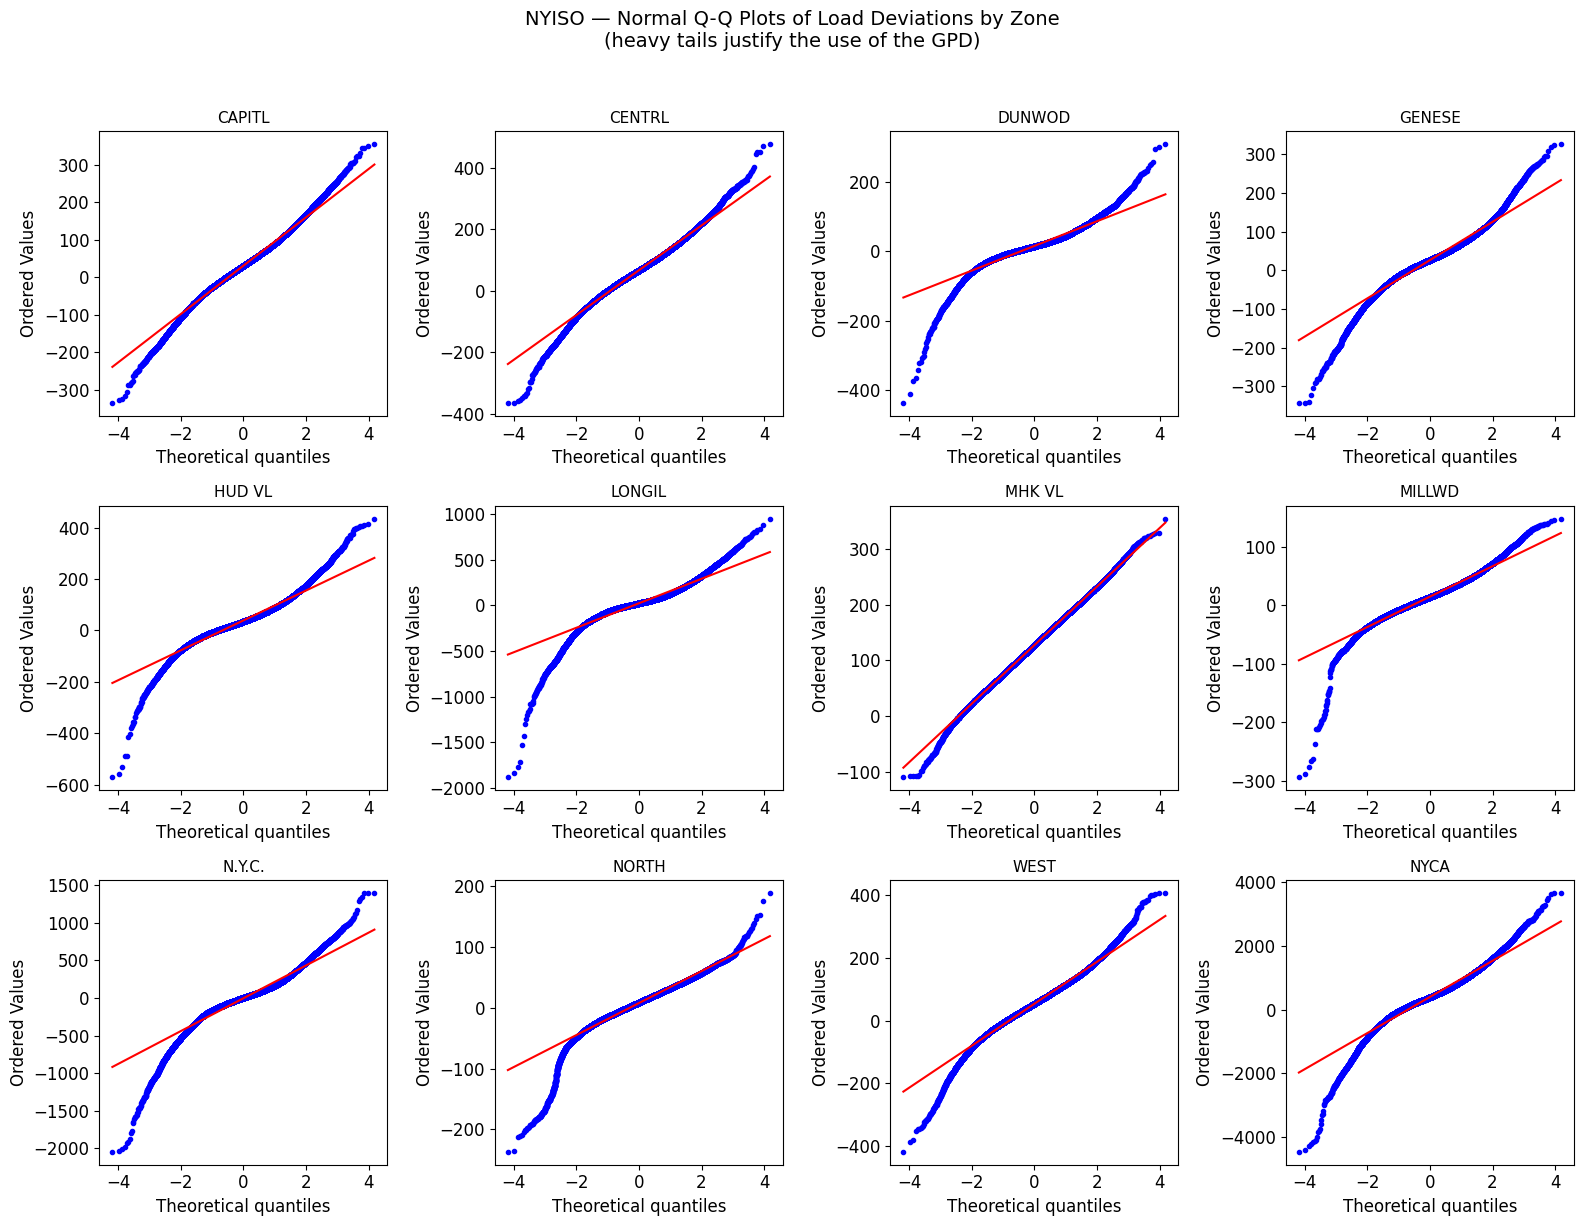

In [ ]:
# --- Q-Q plots of load deviations (cf. Figure 1 in the paper) ---
zones = load_actual.columns
n_zones = len(zones)
n_cols = min(4, n_zones)
n_rows = (n_zones + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = np.atleast_2d(axes)

# Compute deviations for each zone from the model data
model = load_engn.model

for idx, zone in enumerate(zones):
    row, col = idx // n_cols, idx % n_cols
    ax = axes[row, col]
    
    if zone in model.deviation_dict:
        devs = model.deviation_dict[zone]['Deviation'].values
        stats.probplot(devs, dist='norm', plot=ax)
        ax.set_title(f'{zone}', fontsize=11)
        ax.get_lines()[0].set_markersize(3)
    else:
        ax.set_title(f'{zone} — data not found')

# Hide unused axes
for idx in range(n_zones, n_rows * n_cols):
    row, col = idx // n_cols, idx % n_cols
    axes[row, col].set_visible(False)

plt.suptitle('NYISO — Normal Q-Q Plots of Load Deviations by Zone\n'
             '(heavy tails justify the use of the GPD)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 GEMINI Spatio-Temporal Correlations — Load

Visualization of the temporal and spatial components of the conditional
correlation matrix estimated by GEMINI (cf. Figure 3 of the paper for Texas).

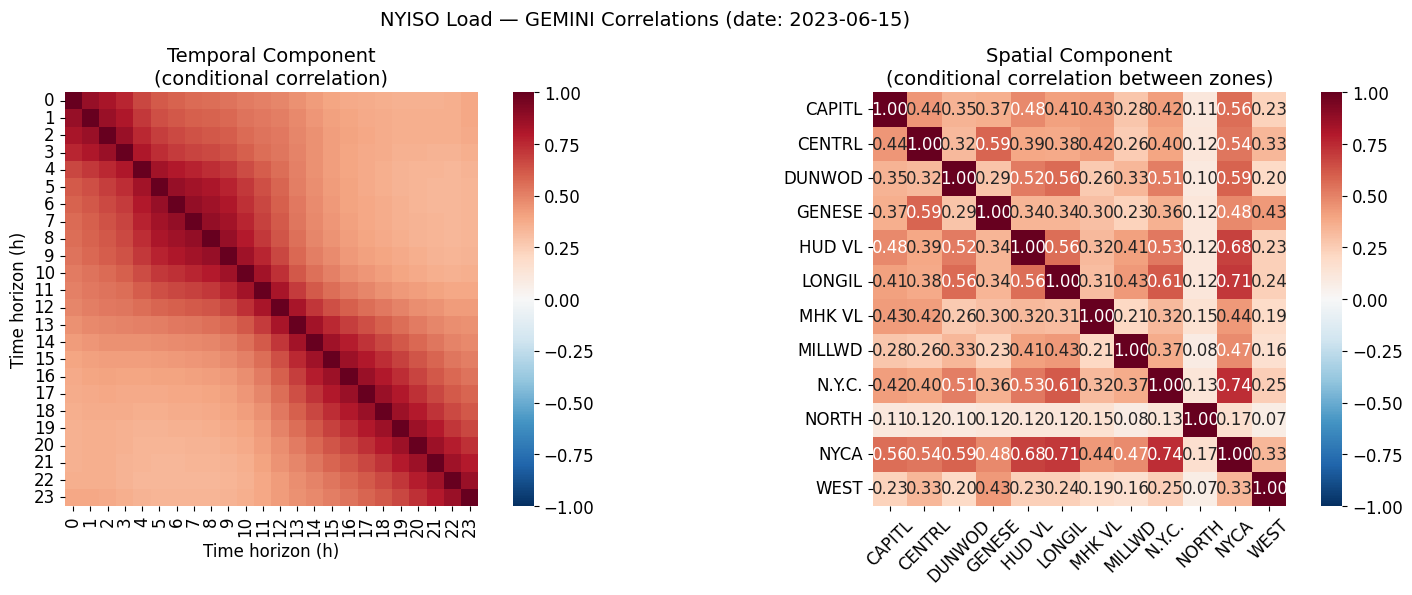

In [9]:
# --- Temporal and spatial correlation of the GEMINI model (Load) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Temporal component
horizon_cov = model.horizon_cov
if horizon_cov is not None:
    # Normalize to correlation
    d = np.sqrt(np.diag(horizon_cov.values))
    horizon_corr = horizon_cov.values / np.outer(d, d)
    
    sns.heatmap(horizon_corr, ax=axes[0], cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True,
                xticklabels=range(24), yticklabels=range(24))
    axes[0].set_title('Temporal Component\n(conditional correlation)')
    axes[0].set_xlabel('Time horizon (h)')
    axes[0].set_ylabel('Time horizon (h)')
else:
    axes[0].text(0.5, 0.5, 'horizon_cov not available', ha='center',
                 transform=axes[0].transAxes)

# Spatial component
asset_cov = model.asset_cov
if asset_cov is not None:
    d = np.sqrt(np.diag(asset_cov.values))
    asset_corr = asset_cov.values / np.outer(d, d)
    
    sns.heatmap(asset_corr, ax=axes[1], cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, annot=True, fmt='.2f',
                xticklabels=asset_cov.columns, yticklabels=asset_cov.index)
    axes[1].set_title('Spatial Component\n(conditional correlation between zones)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)
else:
    axes[1].text(0.5, 0.5, 'asset_cov not available', ha='center',
                 transform=axes[1].transAxes)

plt.suptitle(f'NYISO Load — GEMINI Correlations (date: {SCEN_DATE})', fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 Load Scenario Visualization

Comparison of Monte Carlo scenarios with actual values and forecasts
(see Figure 4 of the paper for Texas).

In [10]:
def plot_scenarios(scenarios_df, actuals_df, forecasts_df, scen_timesteps,
                   asset_names, title_prefix, n_sample=10, n_cols=4):
    """
    Visualize MC scenarios versus actuals and forecasts.
    Reproduces the style of Figures 4 / 10 / 12 in the paper.
    """
    n_assets = len(asset_names)
    n_rows = (n_assets + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_assets == 1:
        axes = np.array([[axes]])
    axes = np.atleast_2d(axes)
    
    hours = range(24)
    
    for idx, asset in enumerate(asset_names):
        row, col = idx // n_cols, idx % n_cols
        ax = axes[row, col]
        
        # Extract scenarios for this asset
        asset_cols = [c for c in scenarios_df.columns if c[0] == asset]
        if not asset_cols:
            # Try matching without tuples
            asset_cols = [(asset, t) for t in scen_timesteps 
                          if (asset, t) in scenarios_df.columns]
        
        if not asset_cols:
            ax.set_title(f'{asset} — no data')
            continue
        
        scen_data = scenarios_df[asset_cols].values  # (n_scen, 24)
        
        # 1%-99% band
        lower = np.percentile(scen_data, 1, axis=0)
        upper = np.percentile(scen_data, 99, axis=0)
        ax.fill_between(hours, lower, upper, alpha=0.3, color='lightblue', label='1%-99%')
        
        # Scenario sample
        sample_idx = np.random.choice(scen_data.shape[0], 
                                       min(n_sample, scen_data.shape[0]), replace=False)
        for i in sample_idx:
            ax.plot(hours, scen_data[i], color='gray', alpha=0.3, linewidth=0.5,
                    label='scenario' if i == sample_idx[0] else None)
        
        # Actuals
        if asset in actuals_df.columns:
            actual_vals = actuals_df.loc[scen_timesteps, asset].values
            ax.plot(hours, actual_vals, 'r-', linewidth=2, label='actual')
        
        # Forecasts
        try:
            fcst = forecasts_df.set_index('Forecast_time')
            if asset in fcst.columns:
                fcst_vals = fcst.loc[scen_timesteps, asset].values
                ax.plot(hours, fcst_vals, 'b-', linewidth=2, label='forecast')
        except Exception:
            pass
        
        ax.set_title(asset, fontsize=10)
        ax.set_xlabel('Hour')
        if idx == 0:
            ax.legend(fontsize=8)
    
    # Hide unused axes
    for idx in range(n_assets, n_rows * n_cols):
        row, col = idx // n_cols, idx % n_cols
        axes[row, col].set_visible(False)
    
    plt.suptitle(f'{title_prefix} — {SCEN_DATE} — {N_SCENARIOS} MC scenarios',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

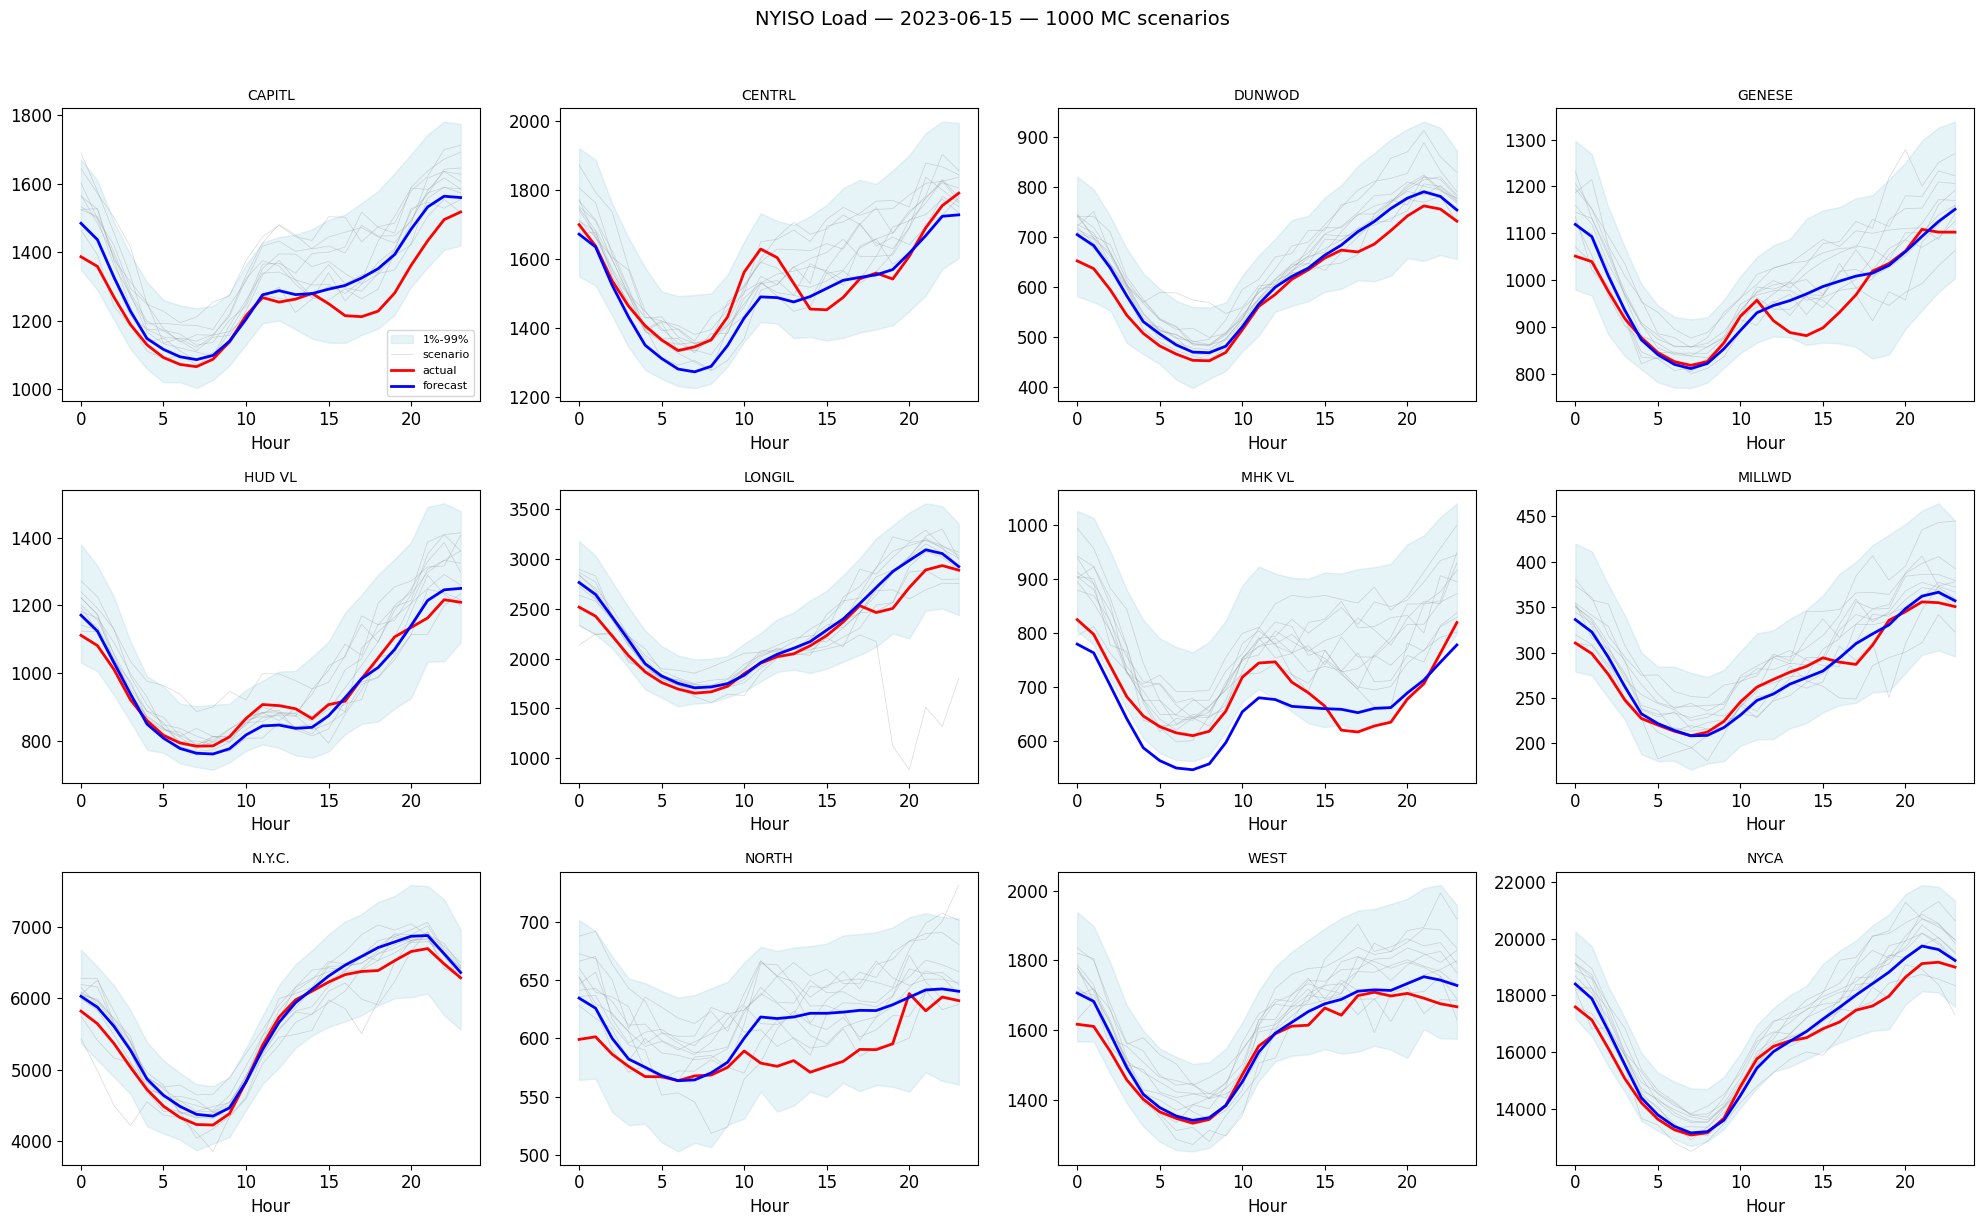

In [11]:
# --- Load scenario visualization ---
plot_scenarios(
    load_engn.scenarios['load'],
    load_actual,
    load_forecast,
    scen_timesteps,
    asset_names=list(load_actual.columns),
    title_prefix='NYISO Load'
)

---
## 3. Wind Scenario Generation (NYISO)

For wind:
- `in_sample=True` (data limited to 2019)
- Use the conditional ECDF for the marginals
- Spatial regularization proportional to distances between sites

In [12]:
# --- WIND scenario generation ---
t0 = time.time()

# Wind data is NREL/PERFORM (2018-2019): lead_time=12h, blocks cover 06:00-05:00 UTC
WIND_SCEN_DATE = '2019-06-15'
wind_scen_start = pd.Timestamp(f'{WIND_SCEN_DATE} 06:00:00', tz='UTC')
wind_scen_timesteps = pd.date_range(wind_scen_start, periods=24, freq='h')

wind_actual_hist, wind_actual_future = split_actuals_hist_future(
    wind_actual, wind_scen_timesteps, in_sample=True)
wind_forecast_hist, wind_forecast_future = split_forecasts_hist_future(
    wind_forecast, wind_scen_timesteps, in_sample=True)

wind_engn = GeminiEngine(
    wind_actual_hist, wind_forecast_hist,
    wind_scen_timesteps[0], wind_meta, asset_type='wind',
    forecast_lead_time_in_hour=12
)

# Spatial regularization proportional to distance
dist = wind_engn.asset_distance().values
wind_engn.fit(2 * ASSET_RHO * dist / dist.max(), TIME_RHO)
wind_engn.create_scenario(N_SCENARIOS, wind_forecast_future)

print(f"Wind scenarios generated in {time.time()-t0:.1f}s")
print(f"Scenario shape: {wind_engn.scenarios['wind'].shape}")

Wind scenarios generated in 9.8s
Scenario shape: (1000, 1920)


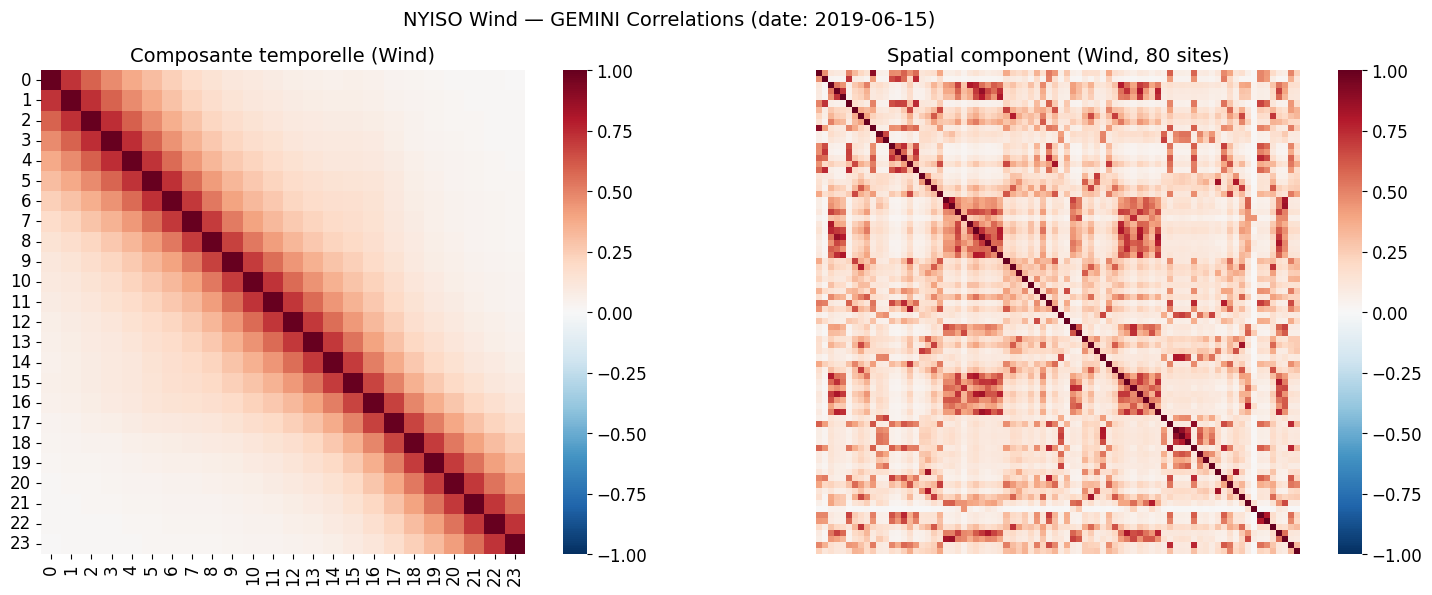

In [30]:
# --- GEMINI correlations — Wind ---
wind_model = wind_engn.model

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Composante temporelle
h_cov = wind_model.horizon_cov
if h_cov is not None:
    d = np.sqrt(np.diag(h_cov.values))
    h_corr = h_cov.values / np.outer(d, d)
    sns.heatmap(h_corr, ax=axes[0], cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True,
                xticklabels=range(24), yticklabels=range(24))
    axes[0].set_title('Composante temporelle (Wind)')

# Composante spatiale — on montre la structure du graphe
a_cov = wind_model.asset_cov
if a_cov is not None:
    d = np.sqrt(np.diag(a_cov.values))
    d[d == 0] = 1  # Avoid division by zero
    a_corr = a_cov.values / np.outer(d, d)
    
    # Pour la lisibilité on montre la heatmap (sans labels si trop de sites)
    show_labels = a_corr.shape[0] <= 30
    sns.heatmap(a_corr, ax=axes[1], cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True,
                xticklabels=a_cov.columns if show_labels else False,
                yticklabels=a_cov.index if show_labels else False)
    axes[1].set_title(f'Spatial component (Wind, {a_corr.shape[0]} sites)')

plt.suptitle(f'NYISO Wind — GEMINI Correlations (date: {WIND_SCEN_DATE})', fontsize=14)
plt.tight_layout()
plt.show()

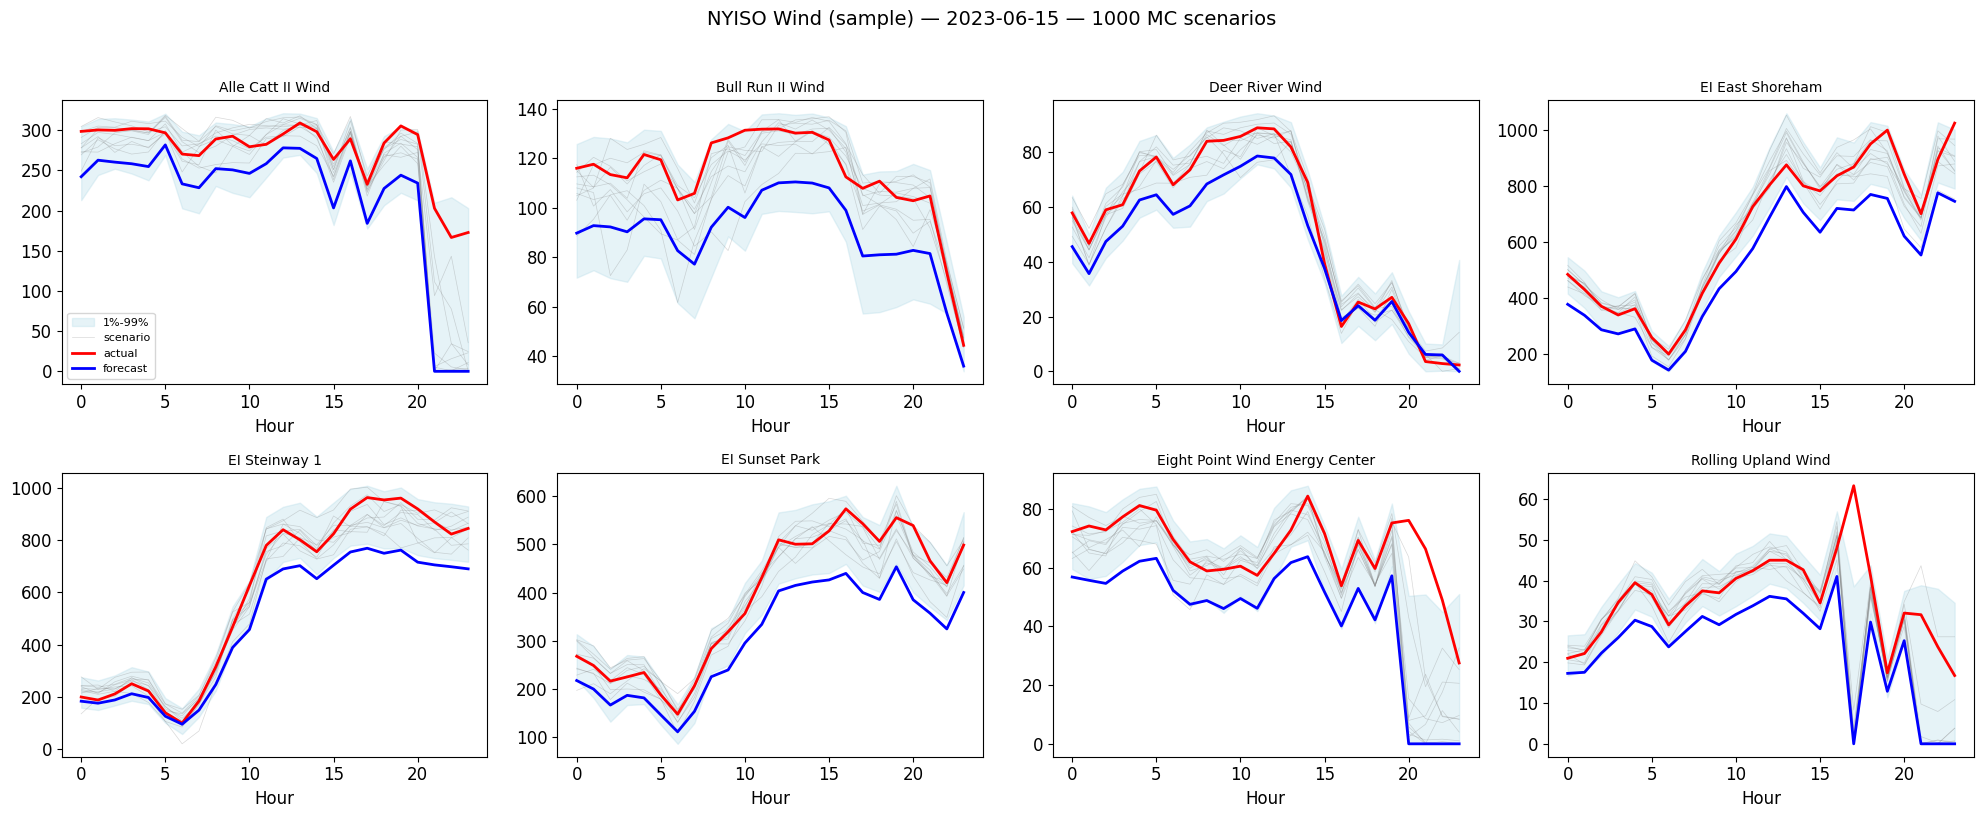

In [32]:
# --- Wind scenario visualization (sample of sites) ---
np.random.seed(42)
wind_sites = list(wind_actual.columns)
n_sample_sites = min(8, len(wind_sites))
sample_wind_sites = sorted(np.random.choice(wind_sites, n_sample_sites, replace=False))

plot_scenarios(
    wind_engn.scenarios['wind'],
    wind_actual,
    wind_forecast,
    wind_scen_timesteps,
    asset_names=sample_wind_sites,
    title_prefix='NYISO Wind (sample)'
)

### 3.1 Forecast-Deviation Dependence (Wind)

Scatterplots of deviations vs forecasts to illustrate that the marginal
distribution of deviations depends on the forecast value (cf. Figure 9).

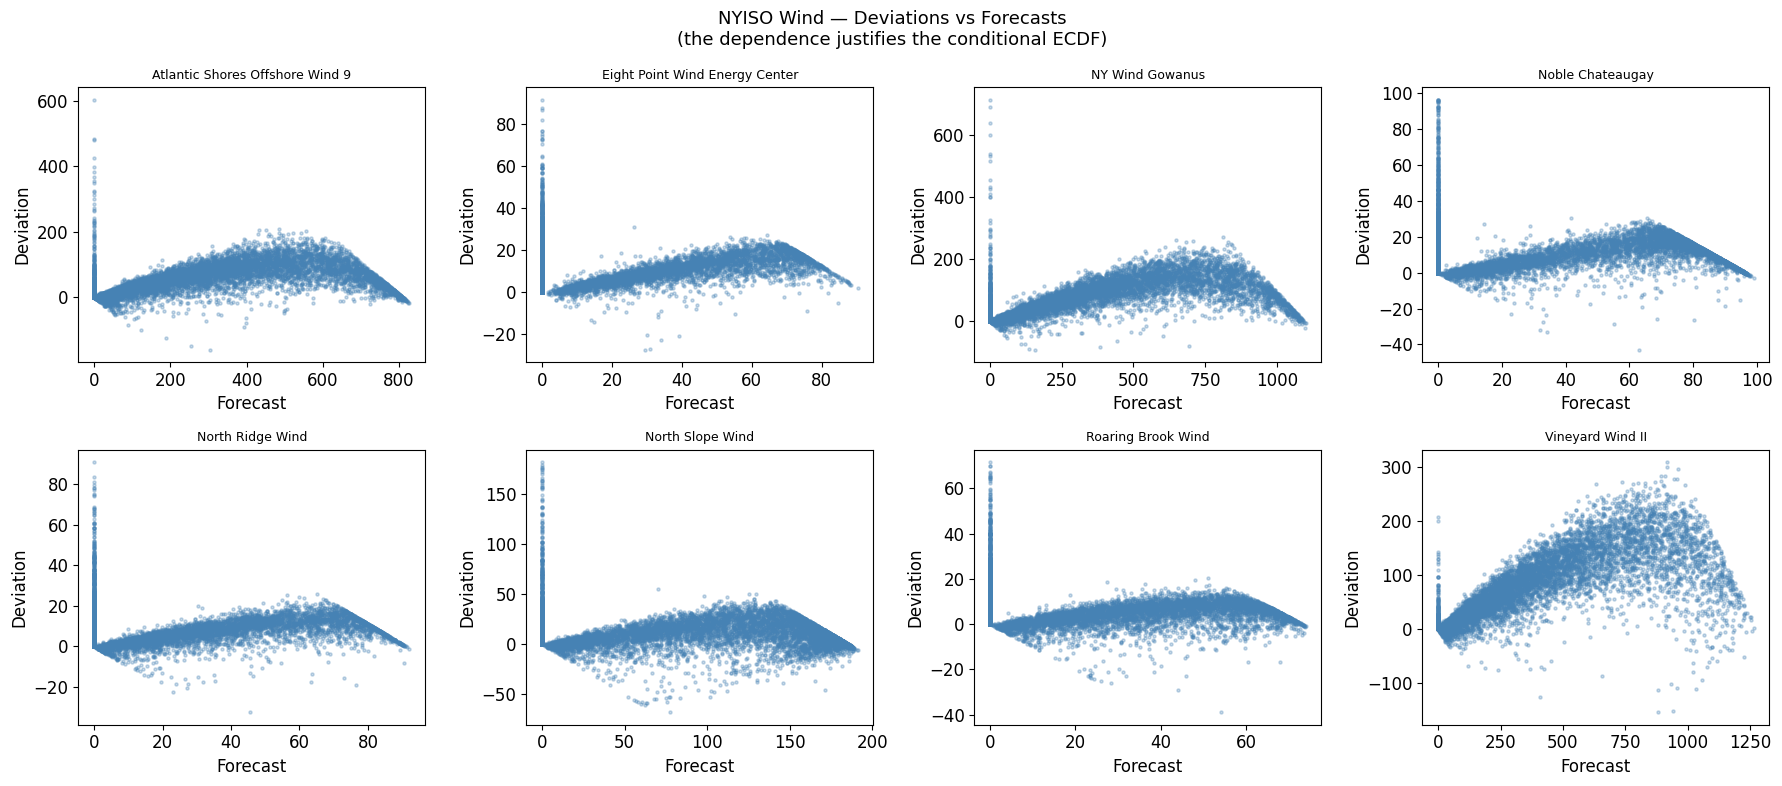

In [15]:
# --- Scatterplot of deviations vs forecasts (Wind) ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
np.random.seed(123)
sample_sites = sorted(np.random.choice(wind_sites, min(8, len(wind_sites)), replace=False))

for ax, site in zip(axes.flat, sample_sites):
    if site in wind_engn.model.deviation_dict:
        dev_data = wind_engn.model.deviation_dict[site]
        ax.scatter(dev_data['Forecast'], dev_data['Deviation'], 
                   alpha=0.3, s=5, c='steelblue')
        ax.set_title(site, fontsize=9)
        ax.set_xlabel('Forecast')
        ax.set_ylabel('Deviation')

plt.suptitle('NYISO Wind — Deviations vs Forecasts\n'
             '(the dependence justifies the conditional ECDF)',
             fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Solar Scenario Generation with PCA (NYISO)

For solar:
- Use `PCAGeminiEngine` to handle the diurnal nature of the signal
- US/Eastern time zone
- PCA projection to reduce the dimensionality of the 24-hour horizon

In [16]:
# --- SOLAR scenario generation ---
t0 = time.time()

# Solar data is NREL/PERFORM (2018-2019): lead_time=12h, blocks cover 06:00-05:00 UTC
SOLAR_SCEN_DATE = '2019-06-15'
solar_scen_start = pd.Timestamp(f'{SOLAR_SCEN_DATE} 06:00:00', tz='UTC')
solar_scen_timesteps = pd.date_range(solar_scen_start, periods=24, freq='h')

solar_actual_hist, solar_actual_future = split_actuals_hist_future(
    solar_actual, solar_scen_timesteps, in_sample=False)
solar_forecast_hist, solar_forecast_future = split_forecasts_hist_future(
    solar_forecast, solar_scen_timesteps, in_sample=False)

solar_engn = PCAGeminiEngine(
    solar_actual_hist, solar_forecast_hist,
    solar_scen_timesteps[0], solar_meta, us_state='New York'
)

dist = solar_engn.asset_distance().values
solar_engn.fit(
    asset_rho=20 * ASSET_RHO * dist / dist.max(),
    pca_comp_rho=TIME_RHO,
    num_of_components=0.9,  # 90% explained variance
    nearest_days=50
)
solar_engn.create_scenario(N_SCENARIOS, solar_forecast_future)

print(f"Solar scenarios generated in {time.time()-t0:.1f}s")
print(f"Scenario shape: {solar_engn.scenarios['solar'].shape}")

Solar scenarios generated in 102.0s
Scenario shape: (1000, 7536)


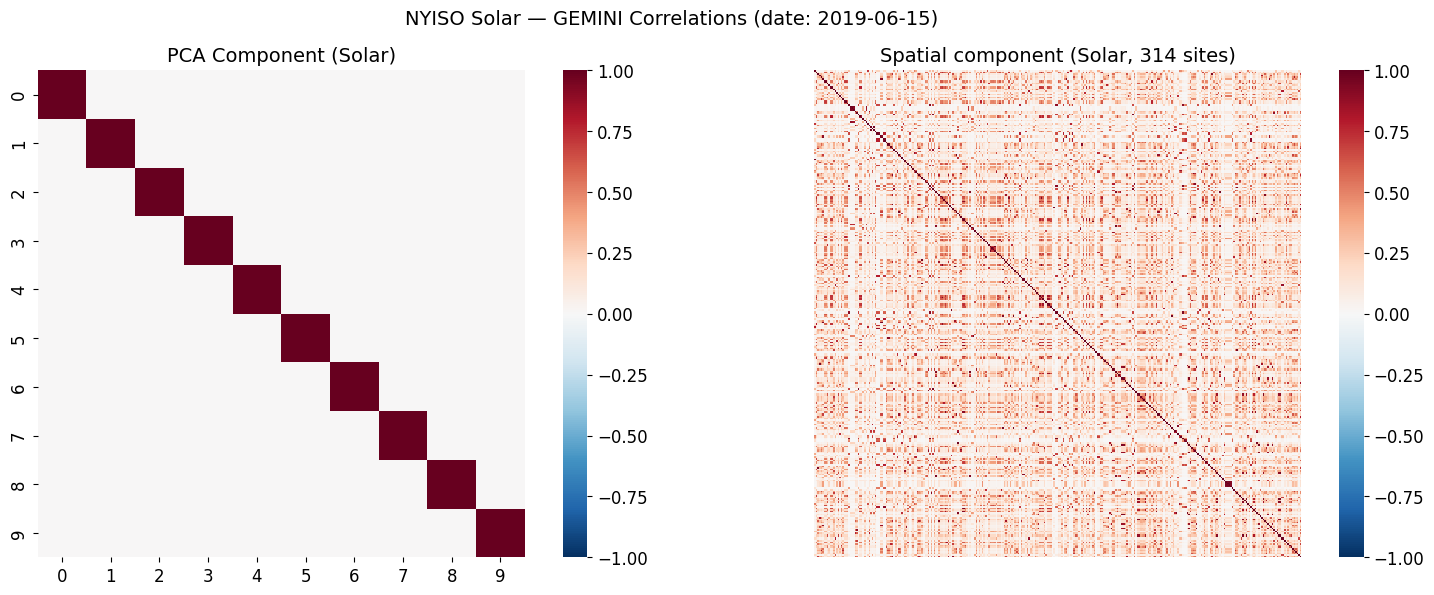

In [33]:
# --- GEMINI correlations — Solar ---
solar_model = solar_engn.model

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA component (temporal)
h_cov = solar_model.horizon_cov
if h_cov is not None:
    d = np.sqrt(np.diag(h_cov.values))
    d[d == 0] = 1
    h_corr = h_cov.values / np.outer(d, d)
    sns.heatmap(h_corr, ax=axes[0], cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True)
    axes[0].set_title('PCA Component (Solar)')

# Spatial component
a_cov = solar_model.asset_cov
if a_cov is not None:
    d = np.sqrt(np.diag(a_cov.values))
    d[d == 0] = 1
    a_corr = a_cov.values / np.outer(d, d)
    show_labels = a_corr.shape[0] <= 30
    sns.heatmap(a_corr, ax=axes[1], cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True,
                xticklabels=a_cov.columns if show_labels else False,
                yticklabels=a_cov.index if show_labels else False)
    axes[1].set_title(f'Spatial component (Solar, {a_corr.shape[0]} sites)')

plt.suptitle(f'NYISO Solar — GEMINI Correlations (date: {SOLAR_SCEN_DATE})', fontsize=14)
plt.tight_layout()
plt.show()

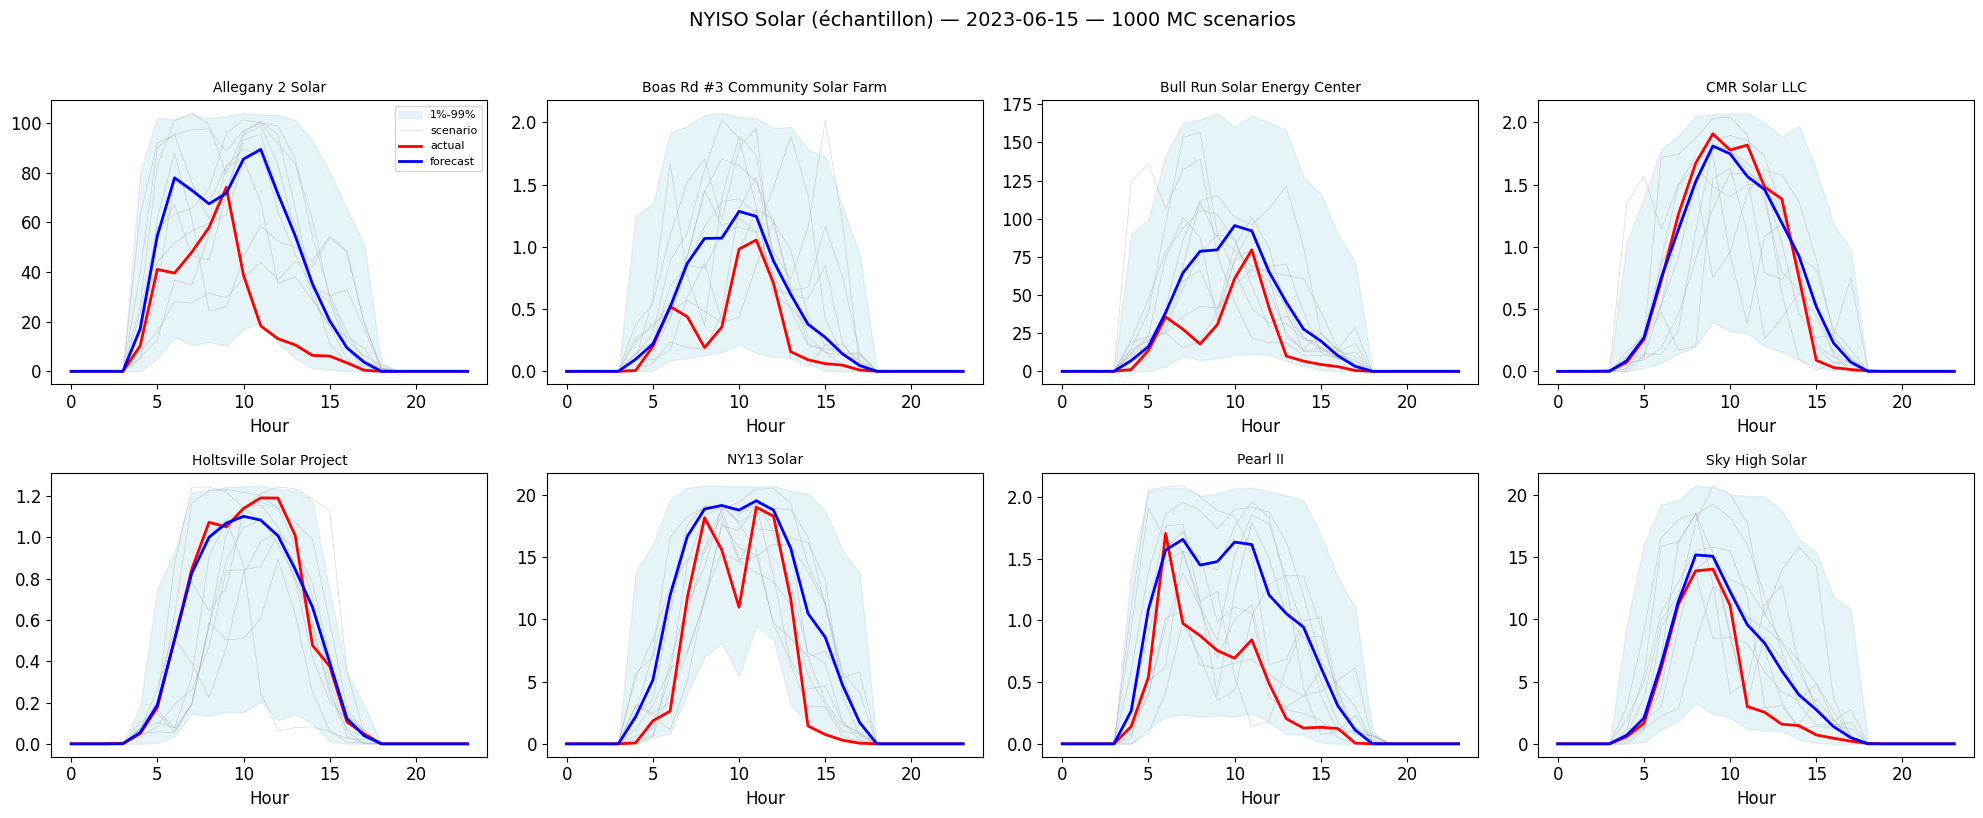

In [18]:
# --- Solar scenario visualization (sample of sites) ---
np.random.seed(42)
solar_sites = list(solar_actual.columns)
n_sample_sites = min(8, len(solar_sites))
sample_solar_sites = sorted(np.random.choice(solar_sites, n_sample_sites, replace=False))

plot_scenarios(
    solar_engn.scenarios['solar'],
    solar_actual,
    solar_forecast,
    solar_scen_timesteps,
    asset_names=sample_solar_sites,
    title_prefix='NYISO Solar (échantillon)'
)

---
## 5. Comparison With and Without Heavy Tails (GPD)

On illustre l'importance de modéliser les queues lourdes pour le load,
comme dans les Figures 5 et 6 de l'article.

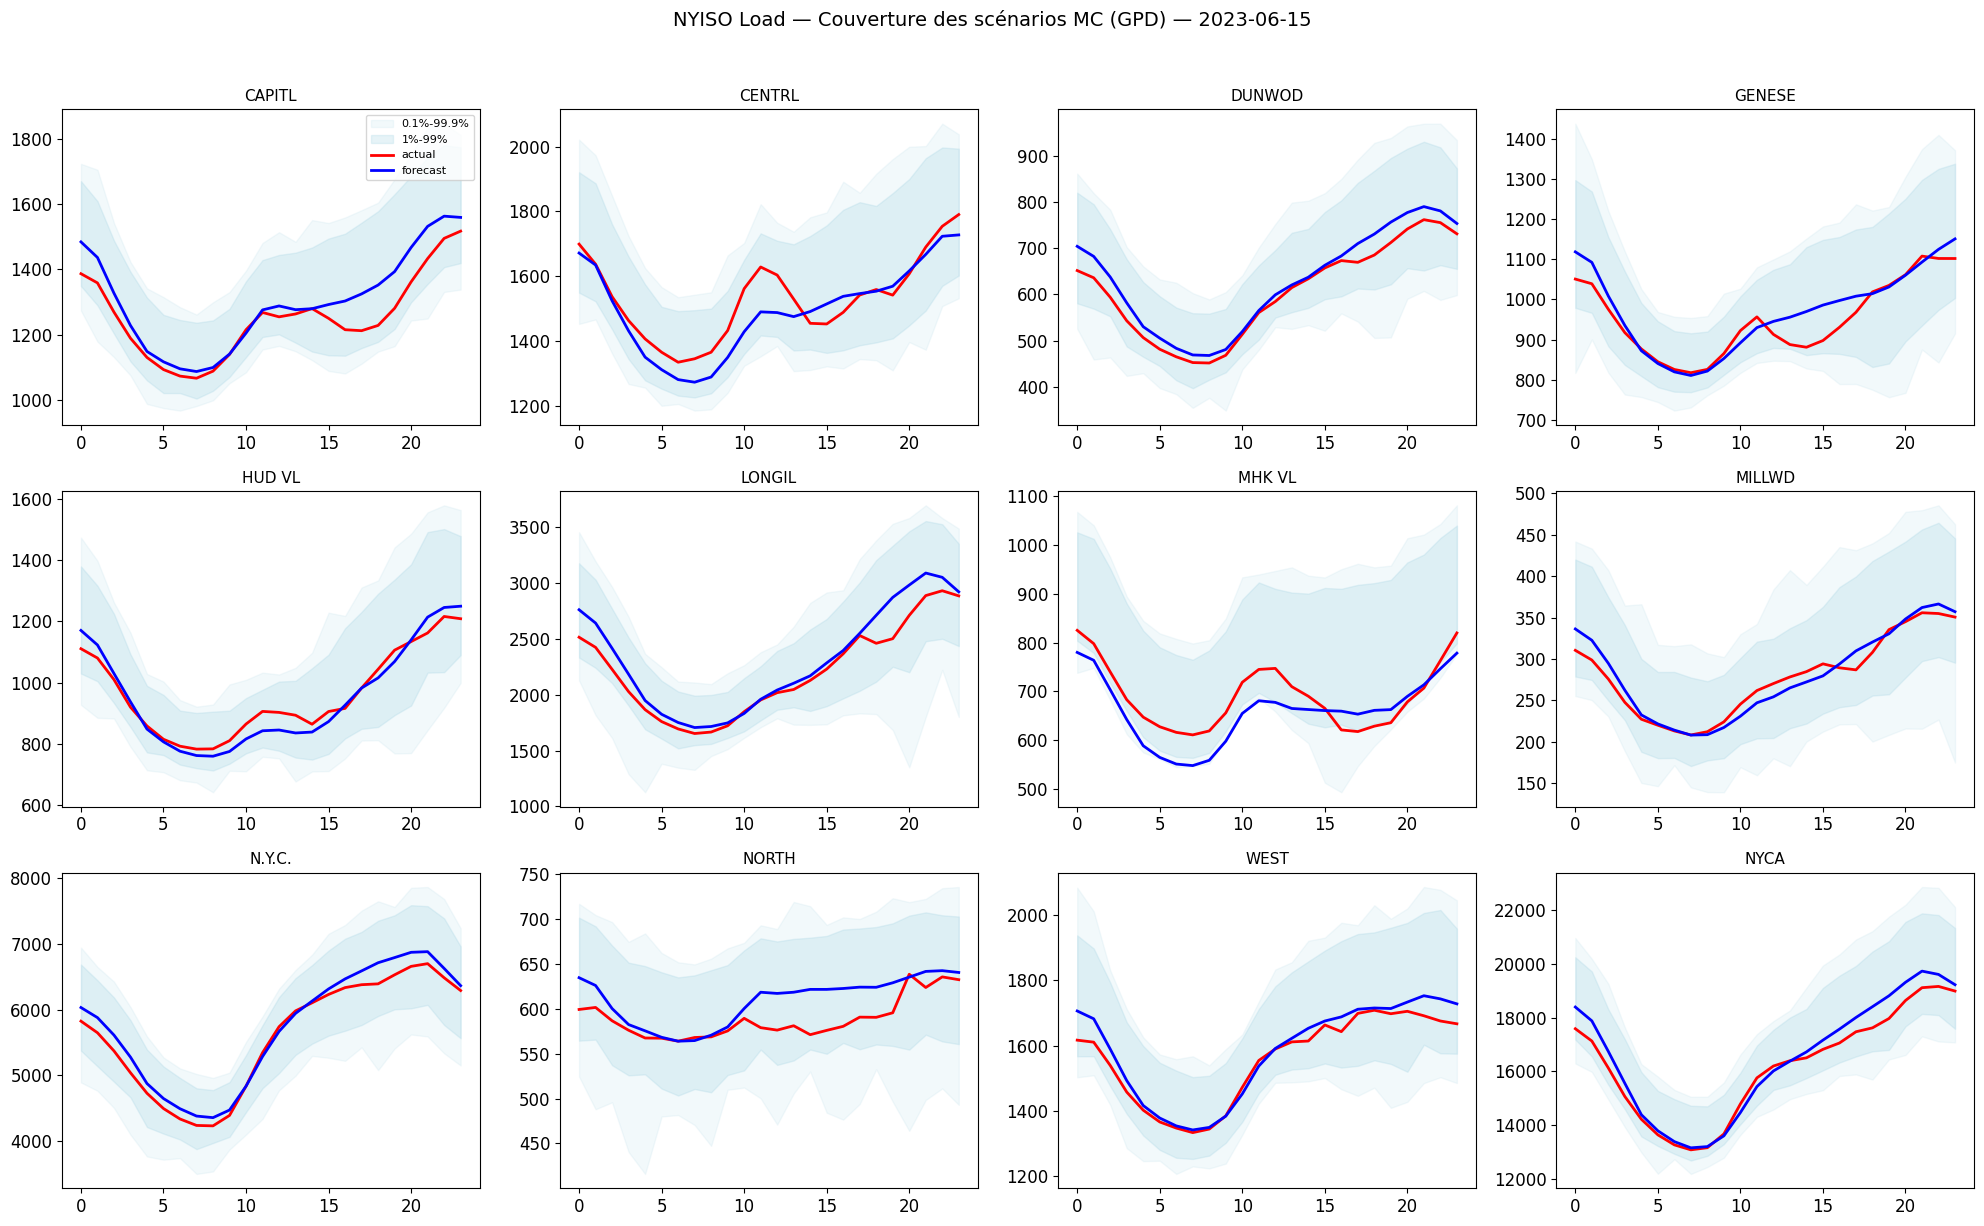

In [19]:
# --- GPD vs Gaussian comparison for a load zone ---
# Existing scenarios use GPD (the default behavior for load)
# Visualize coverage for each zone

zones = load_actual.columns
n_zones = len(zones)
n_cols = min(4, n_zones)
n_rows = (n_zones + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.atleast_2d(axes)

hours = range(24)
scen_df = load_engn.scenarios['load']

for idx, zone in enumerate(zones):
    row, col = idx // n_cols, idx % n_cols
    ax = axes[row, col]
    
    zone_cols = [(zone, t) for t in scen_timesteps 
                 if (zone, t) in scen_df.columns]
    
    if not zone_cols:
        # Try matching by first element
        zone_cols = [c for c in scen_df.columns if c[0] == zone]
    
    if zone_cols:
        data = scen_df[zone_cols].values
        q01 = np.percentile(data, 0.1, axis=0)
        q999 = np.percentile(data, 99.9, axis=0)
        q1 = np.percentile(data, 1, axis=0)
        q99 = np.percentile(data, 99, axis=0)
        
        ax.fill_between(hours, q01, q999, alpha=0.15, color='lightblue', label='0.1%-99.9%')
        ax.fill_between(hours, q1, q99, alpha=0.3, color='lightblue', label='1%-99%')
        
        # Actuals
        if zone in load_actual.columns:
            try:
                actual_vals = load_actual.loc[scen_timesteps, zone].values
                ax.plot(hours, actual_vals, 'r-', linewidth=2, label='actual')
            except Exception:
                pass
        
        # Forecasts
        try:
            fcst = load_forecast.set_index('Forecast_time')
            if zone in fcst.columns:
                fcst_vals = fcst.loc[scen_timesteps, zone].values
                ax.plot(hours, fcst_vals, 'b-', linewidth=2, label='forecast')
        except Exception:
            pass
    
    ax.set_title(zone, fontsize=11)
    if idx == 0:
        ax.legend(fontsize=8)

for idx in range(n_zones, n_rows * n_cols):
    row, col = idx // n_cols, idx % n_cols
    axes[row, col].set_visible(False)

plt.suptitle(f'NYISO Load — Couverture des scénarios MC (GPD) — {SCEN_DATE}',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Évaluation quantitative

### 6.1 Energy Scores

L'energy score est une métrique multivariée pour évaluer la qualité des scénarios.
Un score plus bas indique de meilleurs scénarios.

In [20]:
# --- Energy Scores ---
print("Calcul des Energy Scores...")

try:
    load_escores = compute_energy_scores(
        load_engn.scenarios['load'], load_actual, load_forecast)
    print(f"\n=== Load Energy Scores ===")
    print(load_escores.describe())
    print(f"\nPar zone:")
    print(load_escores)
except Exception as e:
    print(f"Erreur Energy Scores Load: {e}")

try:
    wind_escores = compute_energy_scores(
        wind_engn.scenarios['wind'], wind_actual, wind_forecast)
    print(f"\n=== Wind Energy Scores ===")
    print(wind_escores.describe())
except Exception as e:
    print(f"Erreur Energy Scores Wind: {e}")

try:
    solar_escores = compute_energy_scores(
        solar_engn.scenarios['solar'], solar_actual, solar_forecast)
    print(f"\n=== Solar Energy Scores ===")
    print(solar_escores.describe())
except Exception as e:
    print(f"Erreur Energy Scores Solar: {e}")

Calcul des Energy Scores...

=== Load Energy Scores ===
count      12.000000
mean      473.974130
std       720.425863
min        68.337761
25%       154.907331
50%       245.772388
75%       426.551153
max      2702.725087
dtype: float64

Par zone:
CAPITL     307.324432
CENTRL     204.849373
DUNWOD     142.030966
GENESE     199.963526
HUD VL     159.199453
LONGIL     571.893472
MHK VL     384.722147
MILLWD      68.337761
N.Y.C.     552.038169
NORTH      107.909764
NYCA      2702.725087
WEST       286.695402
dtype: float64

=== Wind Energy Scores ===
count     80.000000
mean      61.611147
std       57.149386
min        0.906574
25%       12.747154
50%       39.677600
75%      103.661382
max      245.939503
dtype: float64

=== Solar Energy Scores ===
count    314.000000
mean      19.913562
std       40.997305
min        0.179002
25%        0.785977
50%        4.868070
75%       10.798955
max      307.627435
dtype: float64


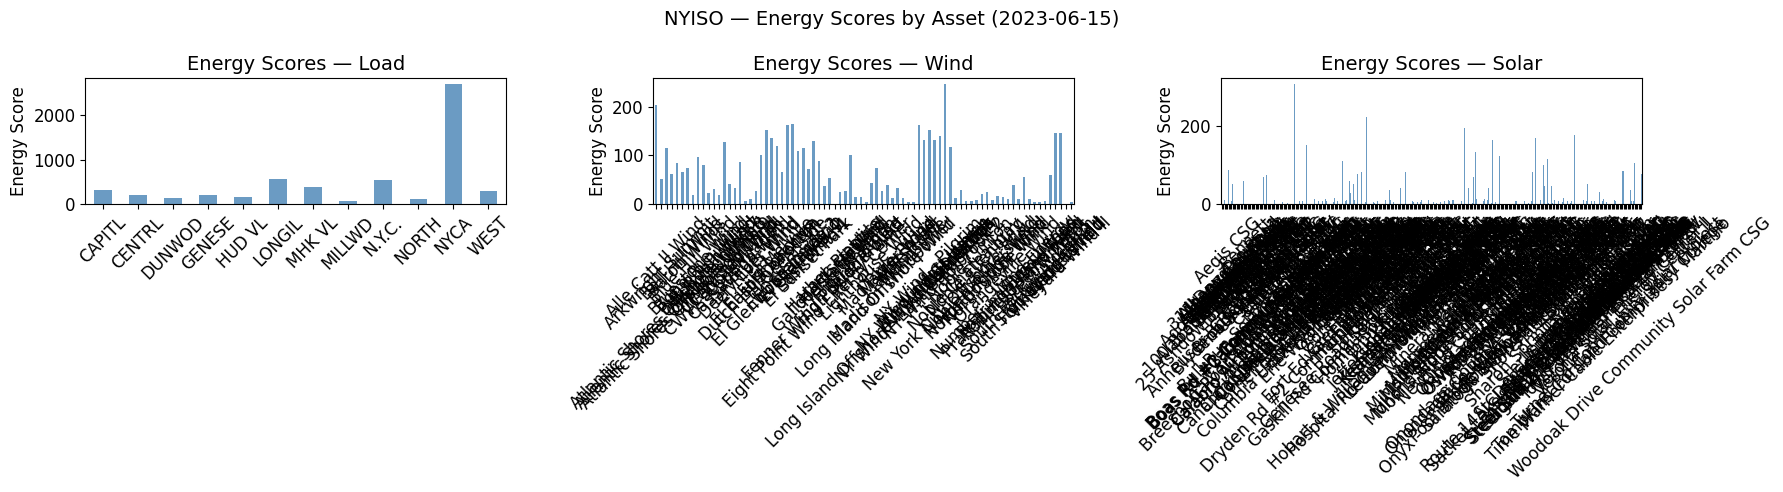

In [21]:
# --- Energy score visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, escores) in zip(axes, [
    ('Load', load_escores if 'load_escores' in dir() else None),
    ('Wind', wind_escores if 'wind_escores' in dir() else None),
    ('Solar', solar_escores if 'solar_escores' in dir() else None)
]):
    if escores is not None and len(escores) > 0:
        escores.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
        ax.set_title(f'Energy Scores — {label}')
        ax.set_ylabel('Energy Score')
        ax.tick_params(axis='x', rotation=45)
        ax.axhline(y=0, color='k', linewidth=0.5)
    else:
        ax.text(0.5, 0.5, f'{label}: not available', 
                ha='center', transform=ax.transAxes)

plt.suptitle(f'NYISO — Energy Scores by Asset ({SCEN_DATE})', fontsize=14)
plt.tight_layout()
plt.show()

### 6.2 Variograms

Variograms measure how well the scenarios capture
temporal dependencies.

In [22]:
# --- Variograms ---
print("Computing variograms...")

try:
    load_varios = compute_variograms(
        load_engn.scenarios['load'], load_actual, load_forecast)
    print(f"\n=== Load Variograms ===")
    print(load_varios.describe())
    print(f"\nBy zone:")
    print(load_varios)
except Exception as e:
    print(f"Load variogram error: {e}")

try:
    wind_varios = compute_variograms(
        wind_engn.scenarios['wind'], wind_actual, wind_forecast)
    print(f"\n=== Wind Variograms ===")
    print(wind_varios.describe())
except Exception as e:
    print(f"Wind variogram error: {e}")

try:
    solar_varios = compute_variograms(
        solar_engn.scenarios['solar'], solar_actual, solar_forecast)
    print(f"\n=== Solar Variograms ===")
    print(solar_varios.describe())
except Exception as e:
    print(f"Solar variogram error: {e}")

Computing variograms...

=== Load Variograms ===
count    1.200000e+01
mean     2.359493e+06
std      6.107938e+06
min      3.579583e+04
25%      1.583292e+05
50%      2.517066e+05
75%      9.014008e+05
max      2.154986e+07
dtype: float64

By zone:
CAPITL    2.447033e+05
CENTRL    5.111443e+05
DUNWOD    6.067810e+04
GENESE    2.787164e+05
HUD VL    2.449778e+05
LONGIL    2.072170e+06
MHK VL    1.908795e+05
MILLWD    3.579583e+04
N.Y.C.    2.814706e+06
NORTH     5.184711e+04
NYCA      2.154986e+07
WEST      2.584354e+05
dtype: float64

=== Wind Variograms ===
count        80.000000
mean     136357.515486
std      197832.101078
min          22.213337
25%        3800.054524
50%       30100.827583
75%      170733.820373
max      730634.630533
dtype: float64

=== Solar Variograms ===
count       314.000000
mean      25077.532834
std       87828.135324
min           1.106269
25%           8.715469
50%         334.111241
75%        1499.531277
max      836315.637994
dtype: float64


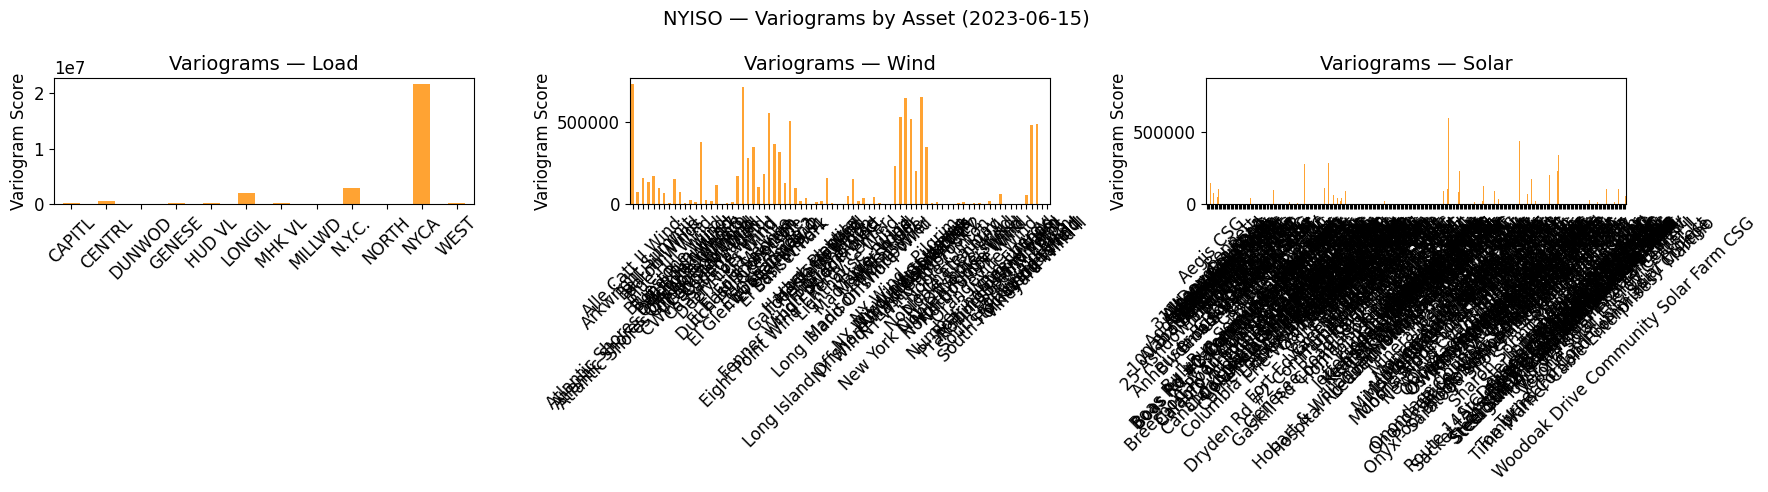

In [23]:
# --- Variogram visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, varios) in zip(axes, [
    ('Load', load_varios if 'load_varios' in dir() else None),
    ('Wind', wind_varios if 'wind_varios' in dir() else None),
    ('Solar', solar_varios if 'solar_varios' in dir() else None)
]):
    if varios is not None and len(varios) > 0:
        varios.plot(kind='bar', ax=ax, color='darkorange', alpha=0.8)
        ax.set_title(f'Variograms — {label}')
        ax.set_ylabel('Variogram Score')
        ax.tick_params(axis='x', rotation=45)
        ax.axhline(y=0, color='k', linewidth=0.5)
    else:
        ax.text(0.5, 0.5, f'{label}: not available',
                ha='center', transform=ax.transAxes)

plt.suptitle(f'NYISO — Variograms by Asset ({SCEN_DATE})', fontsize=14)
plt.tight_layout()
plt.show()

---
## 7. Multi-Day Execution and Robustness Analysis

We generate scenarios over multiple days to evaluate stability
and model robustness on NYISO data.

In [24]:
# --- Multi-day execution ---
# Load uses real NYISO data (START=00:00, lead=6h).
# Wind/Solar use NREL data (START=06:00, lead=12h, restricted to 2019).

LOAD_TEST_DATES = ['2023-01-20', '2023-04-15', '2023-06-15', '2023-08-10', '2023-10-05']
NREL_TEST_DATES = ['2019-02-15', '2019-06-15', '2019-08-10']

multi_day_results = {}

# ── Load scenarios (real NYISO, 00:00 UTC, lead=6h) ──
for date in LOAD_TEST_DATES:
    print(f'\n--- {date} (Load) ---')
    t0 = time.time()
    scen_start_i = pd.Timestamp(f'{date} 00:00:00', tz='UTC')
    scen_ts_i = pd.date_range(scen_start_i, periods=24, freq='h')

    results = multi_day_results.get(date, {})
    try:
        lah, laf = split_actuals_hist_future(load_actual, scen_ts_i, in_sample=False)
        lfh, lff = split_forecasts_hist_future(load_forecast, scen_ts_i, in_sample=False)
        le = GeminiEngine(lah, lfh, scen_ts_i[0], asset_type='load',
                          forecast_lead_time_in_hour=6)
        le.fit(ASSET_RHO, TIME_RHO)
        le.create_scenario(N_SCENARIOS, lff)
        es = compute_energy_scores(le.scenarios['load'], load_actual, load_forecast)
        vr = compute_variograms(le.scenarios['load'], load_actual, load_forecast)
        results['load'] = {'escores': es, 'varios': vr}
        print(f'  Load: OK (mean ES={es.mean():.2f})')
    except Exception as e:
        print(f'  Load: ERROR — {e}')
    multi_day_results[date] = results
    print(f'  Time: {time.time()-t0:.1f}s')

# ── Wind + Solar scenarios (NREL, 06:00 UTC, lead=12h) ──
for date in NREL_TEST_DATES:
    print(f'\n--- {date} (Wind + Solar) ---')
    t0 = time.time()
    scen_start_i = pd.Timestamp(f'{date} 06:00:00', tz='UTC')
    scen_ts_i = pd.date_range(scen_start_i, periods=24, freq='h')

    results = multi_day_results.get(date, {})

    # Wind
    try:
        wah, waf = split_actuals_hist_future(wind_actual, scen_ts_i, in_sample=True)
        wfh, wff = split_forecasts_hist_future(wind_forecast, scen_ts_i, in_sample=True)
        we = GeminiEngine(wah, wfh, scen_ts_i[0], wind_meta, asset_type='wind',
                          forecast_lead_time_in_hour=12)
        wd = we.asset_distance().values
        we.fit(2 * ASSET_RHO * wd / wd.max(), TIME_RHO)
        we.create_scenario(N_SCENARIOS, wff)
        es = compute_energy_scores(we.scenarios['wind'], wind_actual, wind_forecast)
        vr = compute_variograms(we.scenarios['wind'], wind_actual, wind_forecast)
        results['wind'] = {'escores': es, 'varios': vr}
        print(f'  Wind: OK (mean ES={es.mean():.2f})')
    except Exception as e:
        print(f'  Wind: ERROR — {e}')

    # Solar
    try:
        sah, saf = split_actuals_hist_future(solar_actual, scen_ts_i, in_sample=False)
        sfh, sff = split_forecasts_hist_future(solar_forecast, scen_ts_i, in_sample=False)
        se = PCAGeminiEngine(sah, sfh, scen_ts_i[0], solar_meta, us_state='New York')
        sd = se.asset_distance().values
        se.fit(asset_rho=20*ASSET_RHO*sd/sd.max(), pca_comp_rho=TIME_RHO,
               num_of_components=0.9, nearest_days=50)
        se.create_scenario(N_SCENARIOS, sff)
        es = compute_energy_scores(se.scenarios['solar'], solar_actual, solar_forecast)
        vr = compute_variograms(se.scenarios['solar'], solar_actual, solar_forecast)
        results['solar'] = {'escores': es, 'varios': vr}
        print(f'  Solar: OK (mean ES={es.mean():.2f})')
    except Exception as e:
        print(f'  Solar: ERROR — {e}')

    multi_day_results[date] = results
    print(f'  Time: {time.time()-t0:.1f}s')

# Also run Load for NREL dates (they are within real NYISO range too)
for date in NREL_TEST_DATES:
    if 'load' not in multi_day_results.get(date, {}):
        print(f'\n--- {date} (Load) ---')
        t0 = time.time()
        scen_start_i = pd.Timestamp(f'{date} 00:00:00', tz='UTC')
        scen_ts_i = pd.date_range(scen_start_i, periods=24, freq='h')
        results = multi_day_results.get(date, {})
        try:
            lah, laf = split_actuals_hist_future(load_actual, scen_ts_i, in_sample=False)
            lfh, lff = split_forecasts_hist_future(load_forecast, scen_ts_i, in_sample=False)
            le = GeminiEngine(lah, lfh, scen_ts_i[0], asset_type='load',
                              forecast_lead_time_in_hour=6)
            le.fit(ASSET_RHO, TIME_RHO)
            le.create_scenario(N_SCENARIOS, lff)
            es = compute_energy_scores(le.scenarios['load'], load_actual, load_forecast)
            vr = compute_variograms(le.scenarios['load'], load_actual, load_forecast)
            results['load'] = {'escores': es, 'varios': vr}
            print(f'  Load: OK (mean ES={es.mean():.2f})')
        except Exception as e:
            print(f'  Load: ERROR — {e}')
        multi_day_results[date] = results
        print(f'  Time: {time.time()-t0:.1f}s')


--- 2023-01-20 (Load) ---
  Load: OK (mean ES=177.52)
  Time: 3.4s

--- 2023-04-15 (Load) ---
  Load: OK (mean ES=538.00)
  Time: 3.3s

--- 2023-06-15 (Load) ---
  Load: OK (mean ES=476.54)
  Time: 3.8s

--- 2023-08-10 (Load) ---
  Load: OK (mean ES=904.34)
  Time: 3.6s

--- 2023-10-05 (Load) ---
  Load: OK (mean ES=345.38)
  Time: 3.8s

--- 2019-02-15 (Wind + Solar) ---
  Wind: OK (mean ES=59.02)
  Solar: OK (mean ES=18.94)
  Time: 96.9s

--- 2019-06-15 (Wind + Solar) ---
  Wind: OK (mean ES=61.61)
  Solar: OK (mean ES=19.91)
  Time: 174.4s

--- 2019-08-10 (Wind + Solar) ---
  Wind: OK (mean ES=56.42)
  Solar: OK (mean ES=15.56)
  Time: 178.0s

--- 2019-02-15 (Load) ---
  Load: OK (mean ES=280.20)
  Time: 1.9s

--- 2019-06-15 (Load) ---
  Load: OK (mean ES=226.60)
  Time: 1.6s

--- 2019-08-10 (Load) ---
  Load: OK (mean ES=313.33)
  Time: 1.7s


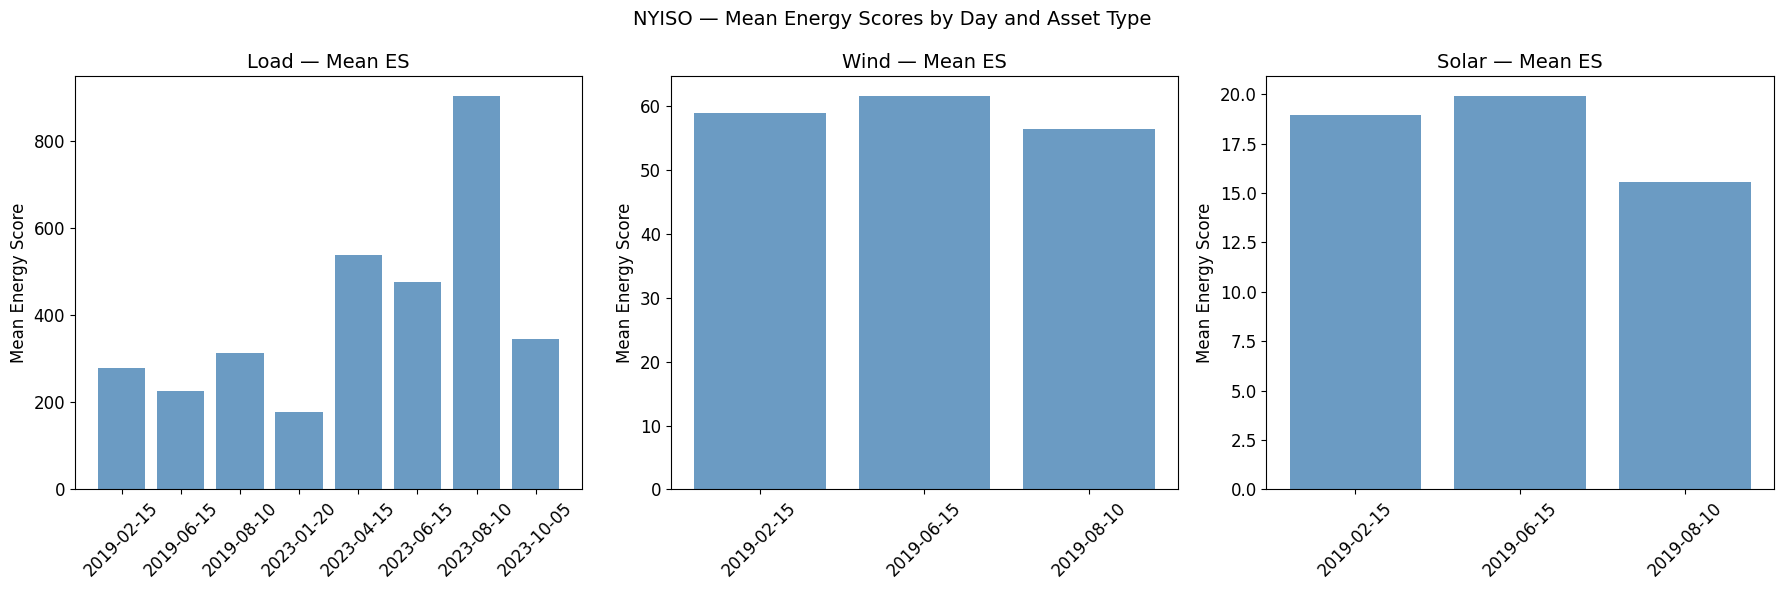

In [25]:
# --- Multi-day summary: mean energy scores ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ALL_DATES = sorted(multi_day_results.keys())

for ax, asset_type in zip(axes, ['load', 'wind', 'solar']):
    dates_ok = [d for d in ALL_DATES if asset_type in multi_day_results.get(d, {})]
    if dates_ok:
        means = [multi_day_results[d][asset_type]['escores'].mean() for d in dates_ok]
        ax.bar(range(len(dates_ok)), means, color='steelblue', alpha=0.8)
        ax.set_xticks(range(len(dates_ok)))
        ax.set_xticklabels(dates_ok, rotation=45)
        ax.set_title(f'{asset_type.capitalize()} — Mean ES')
        ax.set_ylabel('Mean Energy Score')
        ax.axhline(y=0, color='k', linewidth=0.5)
    else:
        ax.text(0.5, 0.5, f'{asset_type}: no result', 
                ha='center', transform=ax.transAxes)

plt.suptitle('NYISO — Mean Energy Scores by Day and Asset Type', fontsize=14)
plt.tight_layout()
plt.show()

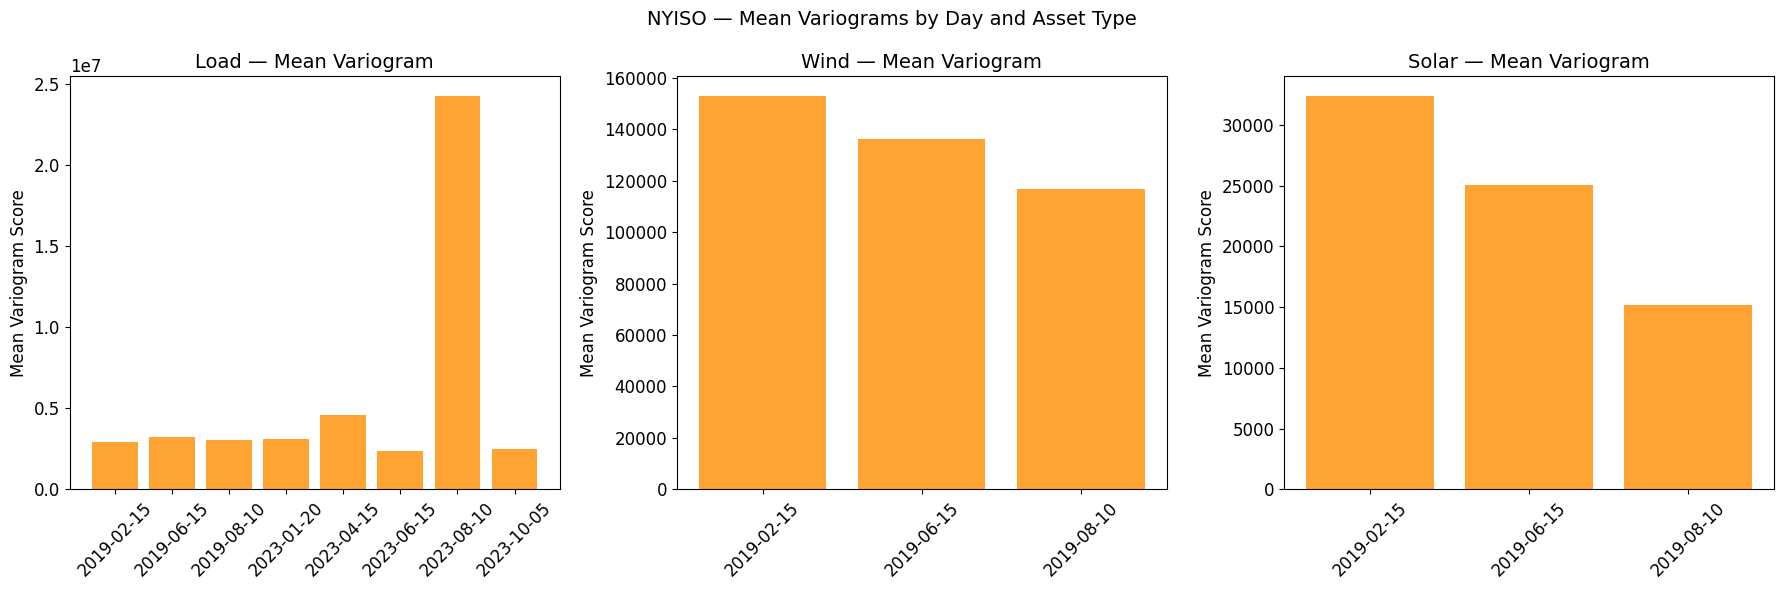

In [26]:
# --- Multi-day summary: mean variograms ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, asset_type in zip(axes, ['load', 'wind', 'solar']):
    dates_ok = [d for d in ALL_DATES if asset_type in multi_day_results.get(d, {})]
    if dates_ok:
        means = [multi_day_results[d][asset_type]['varios'].mean() for d in dates_ok]
        ax.bar(range(len(dates_ok)), means, color='darkorange', alpha=0.8)
        ax.set_xticks(range(len(dates_ok)))
        ax.set_xticklabels(dates_ok, rotation=45)
        ax.set_title(f'{asset_type.capitalize()} — Mean Variogram')
        ax.set_ylabel('Mean Variogram Score')
        ax.axhline(y=0, color='k', linewidth=0.5)
    else:
        ax.text(0.5, 0.5, f'{asset_type}: no result',
                ha='center', transform=ax.transAxes)

plt.suptitle('NYISO — Mean Variograms by Day and Asset Type', fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Summary and Recap Table

In [29]:
# --- Recap table ---
summary_rows = []
for date in ALL_DATES:
    for asset in ['load', 'wind', 'solar']:
        if asset in multi_day_results.get(date, {}):
            res = multi_day_results[date][asset]
            summary_rows.append({
                'Date': date,
                'Asset': asset.capitalize(),
                'ES_mean': res['escores'].mean(),
                'ES_std': res['escores'].std(),
                'Vario_mean': res['varios'].mean(),
                'Vario_std': res['varios'].std(),
            })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    print("\n" + "="*70)
    print("SUMMARY — PGScen NYISO")
    print("="*70)
    print(f"Number of scenarios: {N_SCENARIOS}")
    print(f"Parameters: asset_rho={ASSET_RHO}, time_rho={TIME_RHO}")
    print(f"Tested dates: {len(ALL_DATES)}")
    print("\n")
    display(summary_df.round(4))
    
    print("\n--- Global means ---")
    print(summary_df.groupby('Asset')[['ES_mean', 'Vario_mean']].mean().round(4))
else:
    print("No result available.")


SUMMARY — PGScen NYISO
Number of scenarios: 1000
Parameters: asset_rho=0.1, time_rho=0.1
Tested dates: 8




,Date,Asset,ES_mean,ES_std,Vario_mean,Vario_std
0,2019-02-15,Load,280.2017,363.2537,2.909441e+06,7.970099e+06
1,2019-02-15,Wind,59.0207,79.6554,1.528598e+05,2.957258e+05
2,2019-02-15,Solar,18.9436,36.4631,3.239134e+04,1.063423e+05
3,2019-06-15,Load,226.5971,237.7061,3.213763e+06,9.144697e+06
4,2019-06-15,Wind,61.6148,57.1309,1.363367e+05,1.976782e+05
5,2019-06-15,Solar,19.9111,41.0352,2.505537e+04,8.769885e+04
6,2019-08-10,Load,313.3250,455.3035,3.064996e+06,8.463705e+06
7,2019-08-10,Wind,56.4200,49.9554,1.165947e+05,2.029608e+05
8,2019-08-10,Solar,15.5603,29.5296,1.516682e+04,4.873701e+04
9,2023-01-20,Load,177.5231,221.7426,3.095394e+06,8.621509e+06



--- Global means ---
        ES_mean    Vario_mean
Asset                        
Load   407.7381  5.755449e+06
Solar   18.1383  2.420451e+04
Wind    59.0185  1.352637e+05


---
## 9. Command-Line Usage (Reminder)

To run PGScen NYISO in batch mode from the terminal:

```bash
# All scenario types, 3 days starting from June 15, 2019
pgscen-ny 2019-06-15 3 -n 1000 -v

# Load only
pgscen-ny-load 2019-06-15 5 -n 1000 -v --energy-scores --variograms

# Wind only
pgscen-ny-wind 2019-07-01 3 -n 1000 -v

# Solar only
pgscen-ny-solar 2019-05-20 2 -n 1000 -v -c 0.9

# With pickle output
pgscen-ny 2019-08-01 7 -n 500 -p -o output/nyiso_scenarios
```

### Supported Dates (NYISO)
- **Load**: 2018-2019 data, so scenarios are possible over this period
- **Wind**: 2019 data only (`in_sample`)
- **Solar**: 2018-2019 data